<a href="https://colab.research.google.com/github/anudaindu/Mobitel_Alarm_Fault_Prediction/blob/main/notebooks/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries for EDA

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully for EDA.")

Libraries imported successfully for EDA.


## Load Data

In [15]:
# Define the path to the processed dataset
input_file_path = '/mobi_data2_processed.csv'

# Load the dataset. The file content was verified in the previous step.
df = pd.read_csv(input_file_path)
print(f"Dataset loaded successfully from: {input_file_path}")

# Display shape
print("\nShape of the dataset:", df.shape)

# Display data types and missing values
print("\nData types and non-null values:")
df.info()

# Display missing values count
print("\nMissing values per column:")
print(df.isnull().sum())

# Display duplicate rows count
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Display the first five rows
print("\nFirst five rows of the dataset:")
display(df.head())

Dataset loaded successfully from: /mobi_data2_processed.csv

Shape of the dataset: (192154, 56)

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192154 entries, 0 to 192153
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   occurred_on                      192154 non-null  object 
 1   alarm_id                         192154 non-null  int64  
 2   location_information             192154 non-null  object 
 3   additional_information           192154 non-null  object 
 4   received_on                      192154 non-null  object 
 5   enodeb_id                        192154 non-null  int64  
 6   gnodeb_id                        192154 non-null  object 
 7   alarm_type_encoded               192154 non-null  int64  
 8   severity_encoded                 192154 non-null  int64  
 9   occurred_on_hour                 192154 non-null  int64  
 10 

,occurred_on,alarm_id,location_information,additional_information,received_on,enodeb_id,gnodeb_id,alarm_type_encoded,severity_encoded,occurred_on_hour,...,previous_alarm_type_1,previous_alarm_type_2,previous_alarm_type_3,previous_alarm_type_4,previous_alarm_type_5,time_gap_previous_alarm,sequence_length,alarm_repeat_count,previous_cell_unavailable_count,target
0,2026-07-01 07:17:43,25888,"Link No.=70180, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 07:19:22,0,Unknown,4,3,7,...,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000,0.0,0.0,0.0,0.0
1,2026-07-01 07:26:11,25888,"Link No.=70306, Description=eNodeB:MCC_413 MNC...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 07:27:51,0,Unknown,4,3,7,...,4.0,-1.0,-1.0,-1.0,-1.0,8.466667,1.0,1.0,0.0,0.0
2,2026-07-01 12:08:06,25888,"Link No.=70074, Description=eNodeB:MCC_413 MNC...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 12:09:46,0,Unknown,4,3,12,...,4.0,4.0,-1.0,-1.0,-1.0,281.916667,2.0,2.0,0.0,0.0
3,2026-07-01 18:50:12,65096,"Cabinet No.=0, Subrack No.=0, Slot No.=19, Por...","RAT_INFO=GUL, AFFECTED_RAT=GUL, DID=AUTODID_20...",2026-07-01 18:50:12,0,Unknown,8,3,18,...,4.0,4.0,4.0,-1.0,-1.0,402.100000,3.0,0.0,0.0,0.0
4,2026-07-01 21:45:56,25888,"Link No.=70182, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 21:47:37,0,Unknown,4,3,21,...,8.0,4.0,4.0,4.0,-1.0,175.733333,4.0,3.0,0.0,0.0


## SECTION 1: Dataset Overview

### Objective
Display the dataset's shape, feature count, target distribution, and distinguish between numerical and categorical columns.

In [16]:
# Dataset Shape and Feature Count
print("Dataset Shape:", df.shape)
print("Total number of features (columns):", df.shape[1])

# Target Distribution
print("\nTarget (Cell Unavailable) Distribution:")
display(df['target'].value_counts())
display(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns (", len(numerical_cols), "):", numerical_cols)
print("Categorical Columns (", len(categorical_cols), "):", categorical_cols)

Dataset Shape: (192154, 56)
Total number of features (columns): 56

Target (Cell Unavailable) Distribution:


,count
target,
0.0,159906
1.0,32247


,proportion
target,
0.0,83.22%
1.0,16.78%



Numerical Columns ( 51 ): ['alarm_id', 'enodeb_id', 'alarm_type_encoded', 'severity_encoded', 'occurred_on_hour', 'occurred_on_day', 'occurred_on_weekday', 'occurred_on_month', 'mo_name_encoded', 'alarm_name_encoded', 'alarm_duration_minutes', 'alarm_source_encoded', 'maintenance_status_encoded', 'ne_type_encoded', 'object_type_encoded', 'received_on_hour', 'received_on_day', 'received_on_weekday', 'received_on_month', 'subnet_encoded', 'type_encoded', 'previous_alarm_1', 'previous_alarm_2', 'previous_alarm_3', 'previous_alarm_4', 'previous_alarm_5', 'previous_severity_1', 'previous_severity_2', 'previous_severity_3', 'previous_severity_4', 'previous_severity_5', 'previous_alarm_source_1', 'previous_alarm_source_2', 'previous_alarm_source_3', 'previous_alarm_source_4', 'previous_alarm_source_5', 'previous_object_type_1', 'previous_object_type_2', 'previous_object_type_3', 'previous_object_type_4', 'previous_object_type_5', 'previous_alarm_type_1', 'previous_alarm_type_2', 'previous_al

### Interpretation

- **Dataset Shape:** The dataset contains `df.shape[0]` rows and `df.shape[1]` columns.
- **Missing Values & Duplicates:** There are no missing values or duplicate rows, indicating a clean dataset for analysis.
- **Initial Data Types:** The `df.info()` output shows a mix of numerical (`int64`, `float64`) and object (`object`) types. The 'object' columns typically represent categorical data or strings that may need further processing or encoding if they are not already encoded.

Now, let's explicitly look at the target distribution and column categorization.

### Target Distribution and Column Categorization


Target (Cell Unavailable) Distribution:
Value Counts:


,count
target,
0.0,159906
1.0,32247


Percentages:


,proportion
target,
0.0,83.22%
1.0,16.78%


/tmp/ipykernel_943/3601930870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


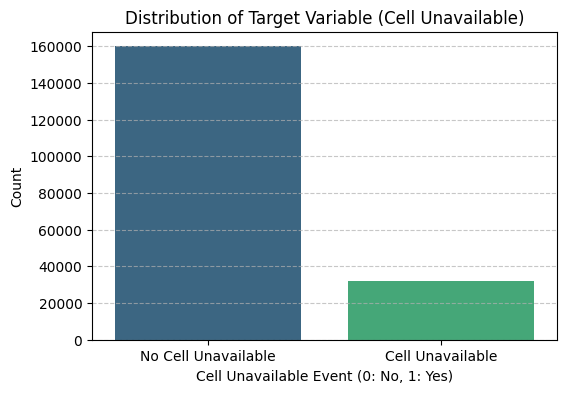


Numerical Columns ( 51 ): ['alarm_id', 'enodeb_id', 'alarm_type_encoded', 'severity_encoded', 'occurred_on_hour', 'occurred_on_day', 'occurred_on_weekday', 'occurred_on_month', 'mo_name_encoded', 'alarm_name_encoded', 'alarm_duration_minutes', 'alarm_source_encoded', 'maintenance_status_encoded', 'ne_type_encoded', 'object_type_encoded', 'received_on_hour', 'received_on_day', 'received_on_weekday', 'received_on_month', 'subnet_encoded', 'type_encoded', 'previous_alarm_1', 'previous_alarm_2', 'previous_alarm_3', 'previous_alarm_4', 'previous_alarm_5', 'previous_severity_1', 'previous_severity_2', 'previous_severity_3', 'previous_severity_4', 'previous_severity_5', 'previous_alarm_source_1', 'previous_alarm_source_2', 'previous_alarm_source_3', 'previous_alarm_source_4', 'previous_alarm_source_5', 'previous_object_type_1', 'previous_object_type_2', 'previous_object_type_3', 'previous_object_type_4', 'previous_object_type_5', 'previous_alarm_type_1', 'previous_alarm_type_2', 'previous_al

In [17]:
# Target Distribution
print("\nTarget (Cell Unavailable) Distribution:")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True).mul(100).round(2)

print("Value Counts:")
display(target_counts)
print("Percentages:")
display(target_percentages.astype(str) + '%')

# Plot Target Distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (Cell Unavailable)')
plt.xlabel('Cell Unavailable Event (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Cell Unavailable', 'Cell Unavailable'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns (", len(numerical_cols), "):", numerical_cols)
print("Categorical Columns (", len(categorical_cols), "):", categorical_cols)

### Interpretation

- **Target Distribution:** The `target` variable shows the distribution of 'Cell Unavailable' events. This distribution will be crucial for understanding class imbalance.
- **Numerical vs. Categorical Columns:** The identified numerical columns include various encoded features and quantities, while categorical columns consist of original string-based identifiers and descriptions. This distinction is vital for applying appropriate EDA techniques.

## SECTION 2: Target Variable Analysis

### Objective
Analyze the target variable (`target`) to understand its distribution, percentage, and assess class imbalance. Explain whether the dataset is balanced.

/tmp/ipykernel_943/3523049688.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


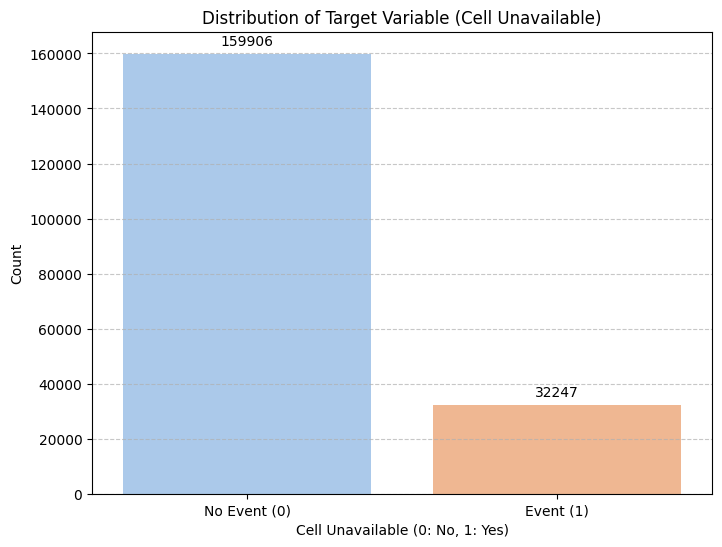


Target Variable Value Counts:


,count
target,
0.0,159906
1.0,32247



Target Variable Percentage Distribution:


,proportion
target,
0.0,83.22%
1.0,16.78%


In [18]:
# Show Count Plot and Percentage
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Distribution of Target Variable (Cell Unavailable)')
plt.xlabel('Cell Unavailable (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Event (0)', 'Event (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

plt.show()

print("\nTarget Variable Value Counts:")
display(df['target'].value_counts())

print("\nTarget Variable Percentage Distribution:")
display(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

### Interpretation

- **Class Imbalance Assessment:** Based on the count plot and percentage distribution, we can determine if the dataset is balanced or imbalanced regarding the 'Cell Unavailable' events. If one class significantly outnumbers the other, it indicates class imbalance, which is a common challenge in predictive modeling, especially in early warning systems.

## SECTION 3: Alarm Frequency Analysis

### Objective
Analyze the `alarm_name_encoded` feature to identify and display the top 20 most frequently occurring alarms. Explain which alarms occur most frequently.

Top 20 Most Frequent Alarms (Encoded):


,count
alarm_name_encoded,
379,112543
471,19185
473,13299
174,5046
470,4453
265,4158
86,3968
318,2627
319,2496


/tmp/ipykernel_943/3012490653.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_alarms.values, y=top_20_alarms.index.astype(str), palette='viridis')


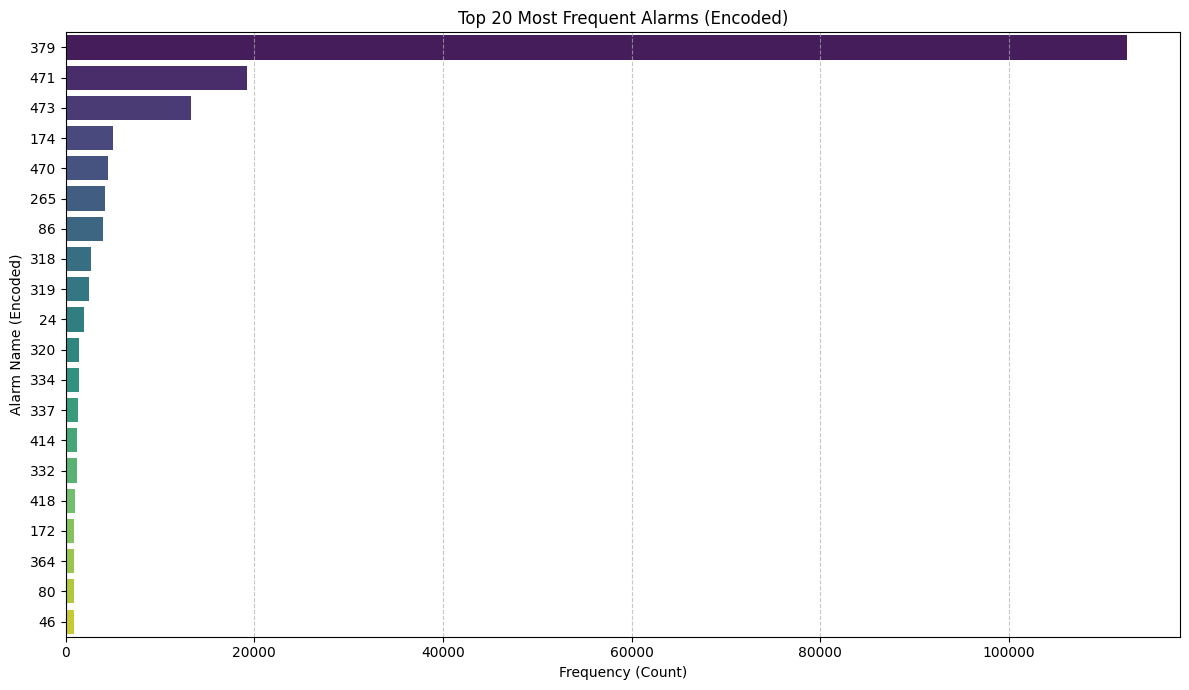

In [19]:
# Calculate the frequency of each alarm
alarm_frequency = df['alarm_name_encoded'].value_counts()

# Get the top 20 most frequent alarms
top_20_alarms = alarm_frequency.head(20)

print("Top 20 Most Frequent Alarms (Encoded):")
display(top_20_alarms)

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x=top_20_alarms.values, y=top_20_alarms.index.astype(str), palette='viridis')
plt.title('Top 20 Most Frequent Alarms (Encoded)')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- The bar plot and the value counts table show the most common `alarm_name_encoded` values. These are the alarms that occur with the highest frequency in the dataset. Identifying these frequent alarms is crucial for understanding the most common issues that telecom towers face. Further investigation would involve mapping these encoded values back to their original alarm names to understand their practical implications.

## SECTION 4: Severity Analysis

### Objective
Analyze the `severity_encoded` feature by displaying its distribution and examining its relationship with the target variable ('Cell Unavailable').

Distribution of Severity Levels (Encoded):


,count
severity_encoded,
1,13079
2,11320
3,162309
4,5446


,proportion
severity_encoded,
3,84.47%
1,6.81%
2,5.89%
4,2.83%


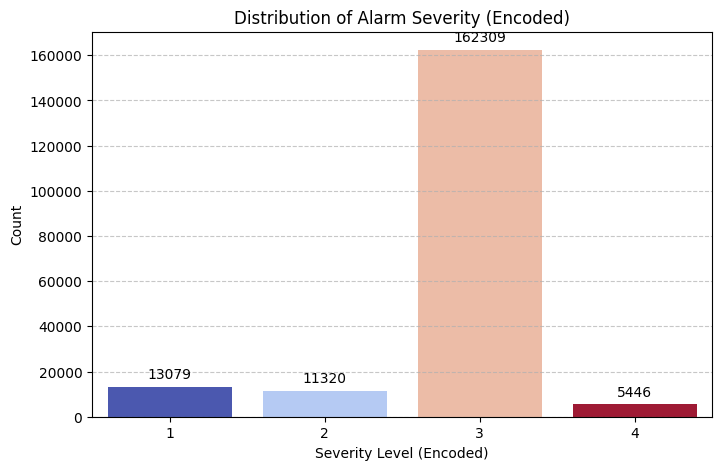


Severity vs Target (Cell Unavailable):


target,0.0,1.0
severity_encoded,,
1,92.29%,7.71%
2,62.97%,37.03%
3,86.06%,13.94%
4,18.69%,81.31%


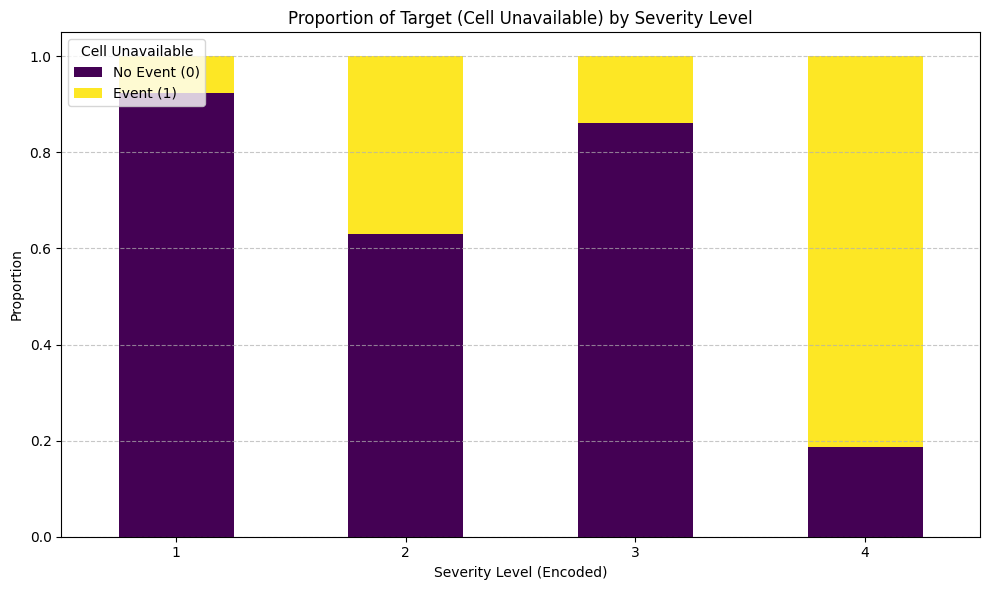

In [20]:
# 1. Distribution of Severity_encoded
print("Distribution of Severity Levels (Encoded):")
severity_counts = df['severity_encoded'].value_counts().sort_index()
severity_percentages = df['severity_encoded'].value_counts(normalize=True).mul(100).round(2)

display(severity_counts)
display(severity_percentages.astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.barplot(x=severity_counts.index, y=severity_counts.values, hue=severity_counts.index, palette='coolwarm', legend=False)
plt.title('Distribution of Alarm Severity (Encoded)')
plt.xlabel('Severity Level (Encoded)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

plt.show()

# 2. Severity vs Target
print("\nSeverity vs Target (Cell Unavailable):")
severity_target = df.groupby('severity_encoded')['target'].value_counts(normalize=True).unstack().fillna(0)
display(severity_target.mul(100).round(2).astype(str) + '%')

severity_target.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proportion of Target (Cell Unavailable) by Severity Level')
plt.xlabel('Severity Level (Encoded)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Cell Unavailable', labels=['No Event (0)', 'Event (1)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- **Severity Distribution:** The distribution of `severity_encoded` reveals the most common severity levels of alarms in the dataset. This helps in understanding the general 'health' of the network or the types of alarms that are frequently triggered.
- **Severity vs. Target:** By analyzing the proportion of 'Cell Unavailable' events for each severity level, we can identify if certain severity levels are more predictive of a 'Cell Unavailable' event. For instance, if higher severity alarms correlate with a higher probability of the target event, it highlights their importance in the early warning system.

## SECTION 5: Alarm Source Analysis

### Objective
Analyze the `alarm_source_encoded` feature to identify and display the top alarm sources.

Top Alarm Sources (Encoded):


,count
alarm_source_encoded,
610,2166
1310,1971
4538,1811
650,1726
4339,1634
571,1609
4398,1561
738,1544
5267,1395


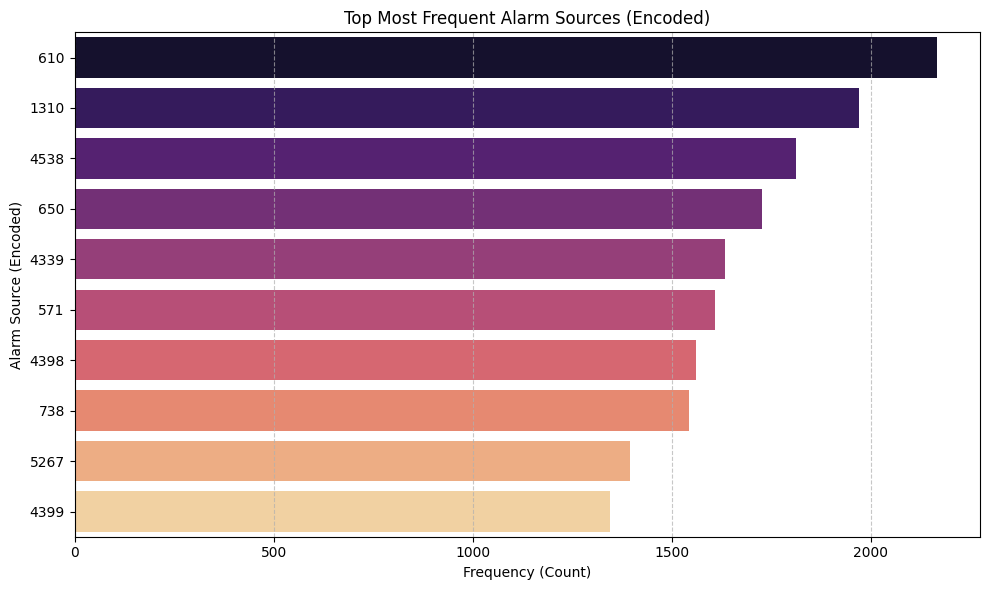

In [21]:
# Calculate the frequency of each alarm source
alarm_source_frequency = df['alarm_source_encoded'].value_counts()

# Get the top 10 (or desired number) most frequent alarm sources
top_alarm_sources = alarm_source_frequency.head(10)

print("Top Alarm Sources (Encoded):")
display(top_alarm_sources)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top_alarm_sources.values, y=top_alarm_sources.index.astype(str), hue=top_alarm_sources.index.astype(str), palette='magma', legend=False)
plt.title('Top Most Frequent Alarm Sources (Encoded)')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Source (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- The bar plot and the value counts table highlight the most frequent `alarm_source_encoded` values. These represent the primary locations or components from which alarms originate. Understanding these sources can help in pinpointing problematic areas within the telecom network, allowing for targeted maintenance or system improvements. Further analysis would involve mapping these encoded values back to their original names.

## SECTION 6: Object Type Analysis

### Objective
Analyze the `object_type_encoded` feature and display its distribution.

Distribution of Object Types (Encoded):


,count
object_type_encoded,
34,112581
43,36696
44,13724
3,12913
6,5585
14,5046
32,4641
9,778
45,118


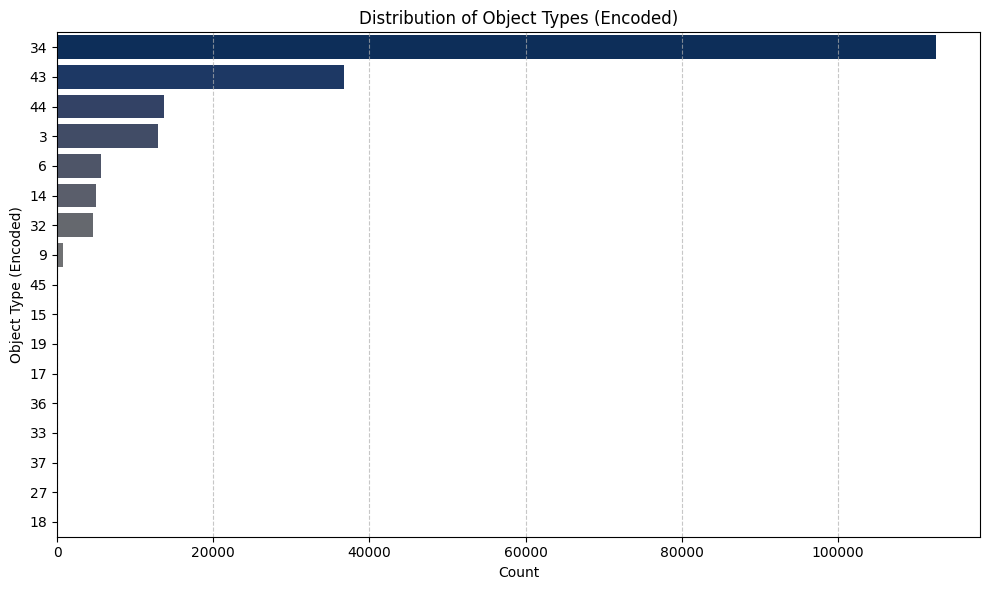

In [22]:
# Calculate the frequency of each object type
object_type_counts = df['object_type_encoded'].value_counts()

print("Distribution of Object Types (Encoded):")
display(object_type_counts)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=object_type_counts.values, y=object_type_counts.index.astype(str), hue=object_type_counts.index.astype(str), palette='cividis', legend=False)
plt.title('Distribution of Object Types (Encoded)')
plt.xlabel('Count')
plt.ylabel('Object Type (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- The distribution of `object_type_encoded` reveals the types of network objects most frequently associated with alarms. This information helps in understanding which components or entities within the telecom infrastructure are more prone to issues, guiding maintenance and resource allocation efforts. Mapping these encoded values to their actual object types would provide more concrete insights.

## SECTION 7: Sequence Length Analysis

### Objective
Analyze the `sequence_length` feature. This feature likely represents the number of alarms in a sequence leading up to an event. Display its distribution and identify typical sequence lengths.

Distribution of Sequence Lengths:


,count
sequence_length,
0.0,929
1.0,926
2.0,924
3.0,923
4.0,921
...,...
2161.0,1
2162.0,1
2163.0,1


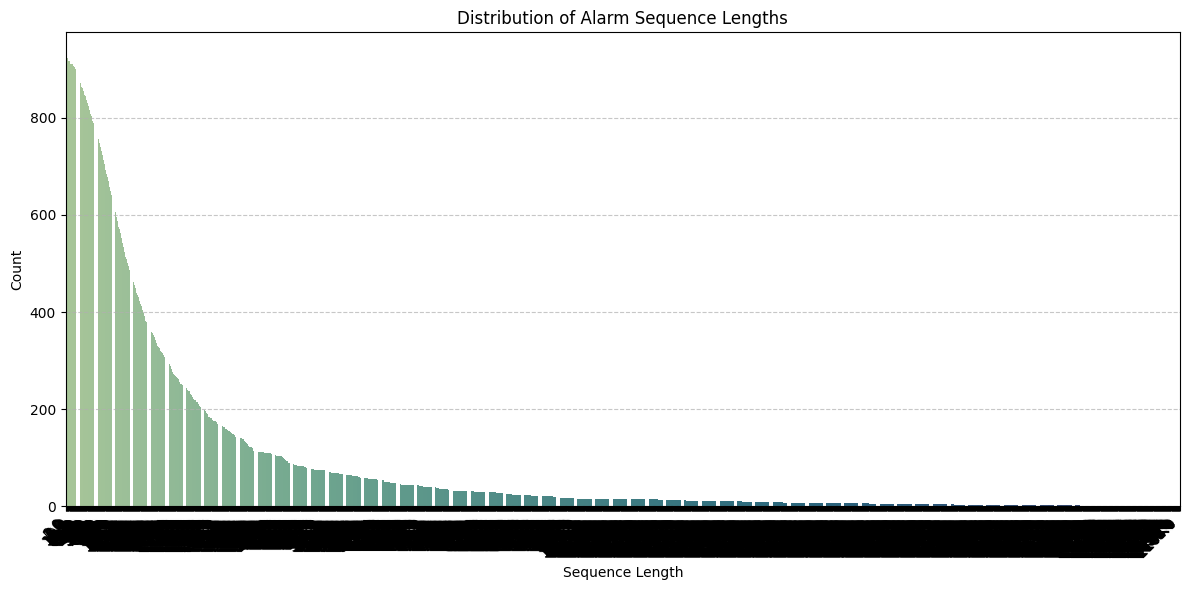

In [23]:
# Calculate the frequency of each sequence length
sequence_length_counts = df['sequence_length'].value_counts().sort_index()

print("Distribution of Sequence Lengths:")
display(sequence_length_counts)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=sequence_length_counts.index, y=sequence_length_counts.values, hue=sequence_length_counts.index, palette='crest', legend=False)
plt.title('Distribution of Alarm Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation
- The distribution of `sequence_length` indicates how many alarms typically precede a 'Cell Unavailable' event in a sequence. Understanding common sequence lengths can help in identifying patterns that lead to the target event. For example, a high frequency of shorter sequences might suggest immediate impact events, while longer sequences could indicate a deteriorating condition over time.

## SECTION 8: Alarm Sequence Analysis (Most Important)

### Objective
Analyze alarm progression before every 'Cell Unavailable' event.

For every 'Cell Unavailable' event, we will identify:

*   Previous Alarm (1 alarm before)
*   Previous 2 Alarm Sequence
*   Previous 3 Alarm Sequence
*   Previous 5 Alarm Sequence

We will then calculate their frequencies, percentages, and identify the most common sequences. Finally, we will create clear tables and bar charts to visualize these findings.

Number of 'Cell Unavailable' events after dropping NaNs for previous alarms: 32247

--- Analysis of 1 Alarm Before Cell Unavailable ---


,Previous_Alarm_1_Encoded,Count,Percentage
0,379.0,13042,40.44
1,86.0,3968,12.31
2,174.0,2820,8.74
3,471.0,1381,4.28
4,337.0,1099,3.41
5,473.0,1000,3.10
6,320.0,876,2.72
7,318.0,777,2.41
8,334.0,730,2.26
9,265.0,641,1.99


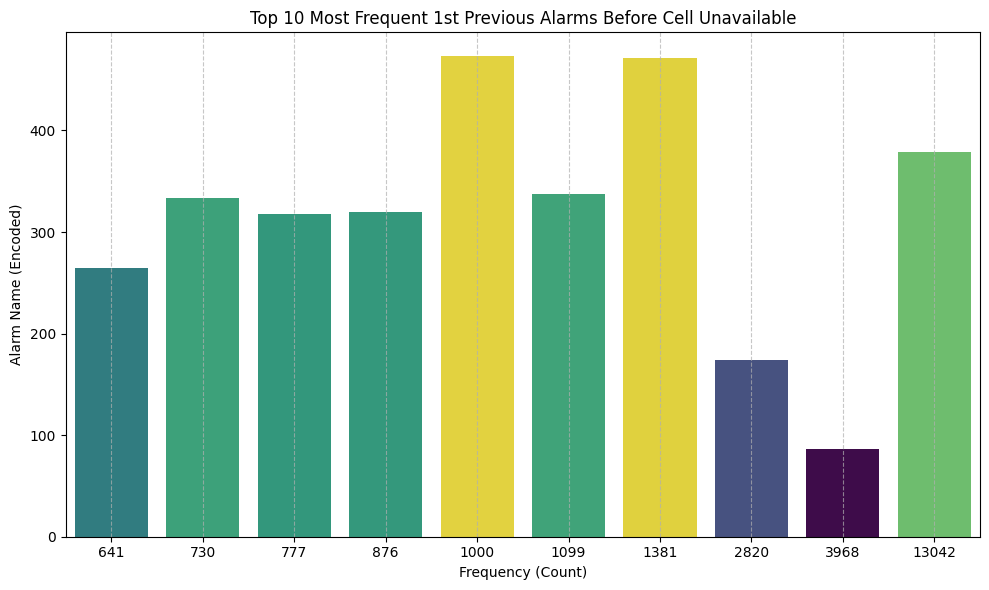


--- Analysis of 2 Alarm Sequence Before Cell Unavailable ---


,Sequence,Count,Percentage
0,379.0 -> 379.0,11221,34.80
1,86.0 -> 86.0,2881,8.93
2,174.0 -> 174.0,2630,8.16
3,471.0 -> 471.0,981,3.04
4,320.0 -> 320.0,651,2.02
5,337.0 -> 337.0,507,1.57
6,379.0 -> 473.0,501,1.55
7,334.0 -> 334.0,426,1.32
8,473.0 -> 379.0,417,1.29
9,80.0 -> 80.0,400,1.24


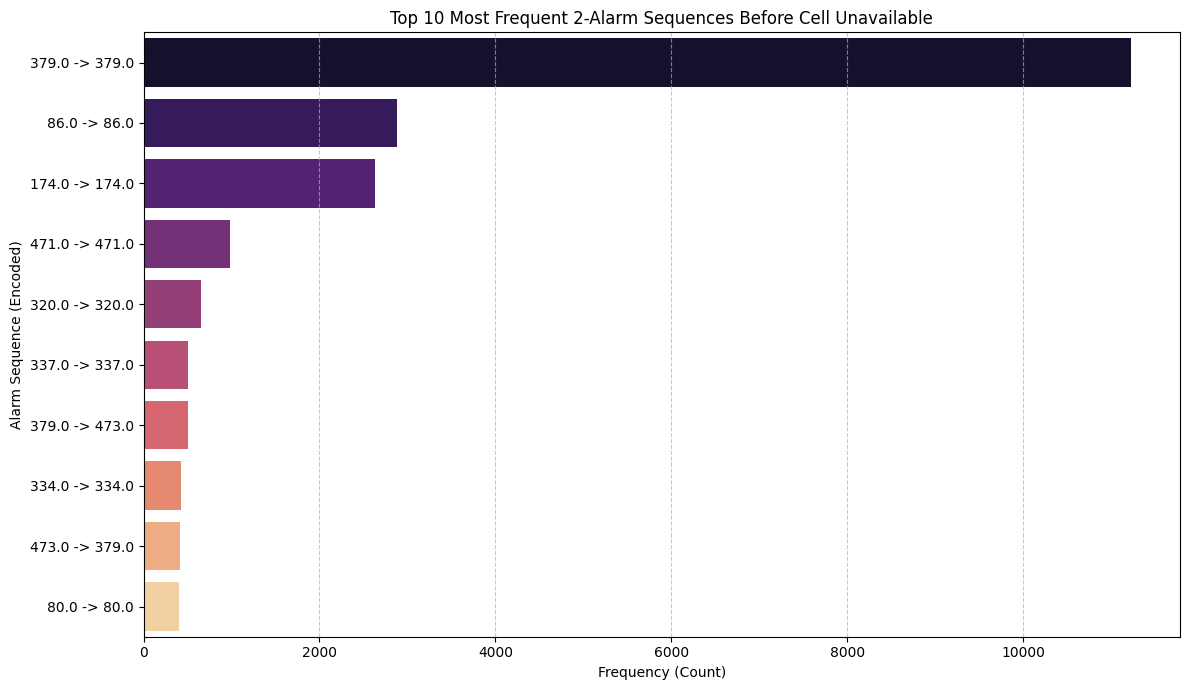


--- Analysis of 3 Alarm Sequence Before Cell Unavailable ---


,Sequence,Count,Percentage
0,379.0 -> 379.0 -> 379.0,10155,31.49
1,174.0 -> 174.0 -> 174.0,2441,7.57
2,86.0 -> 86.0 -> 86.0,2168,6.72
3,471.0 -> 471.0 -> 471.0,808,2.51
4,320.0 -> 320.0 -> 320.0,559,1.73
5,80.0 -> 80.0 -> 80.0,350,1.09
6,379.0 -> 379.0 -> 473.0,309,0.96
7,379.0 -> 473.0 -> 379.0,289,0.90
8,337.0 -> 337.0 -> 337.0,278,0.86
9,473.0 -> 379.0 -> 379.0,266,0.82


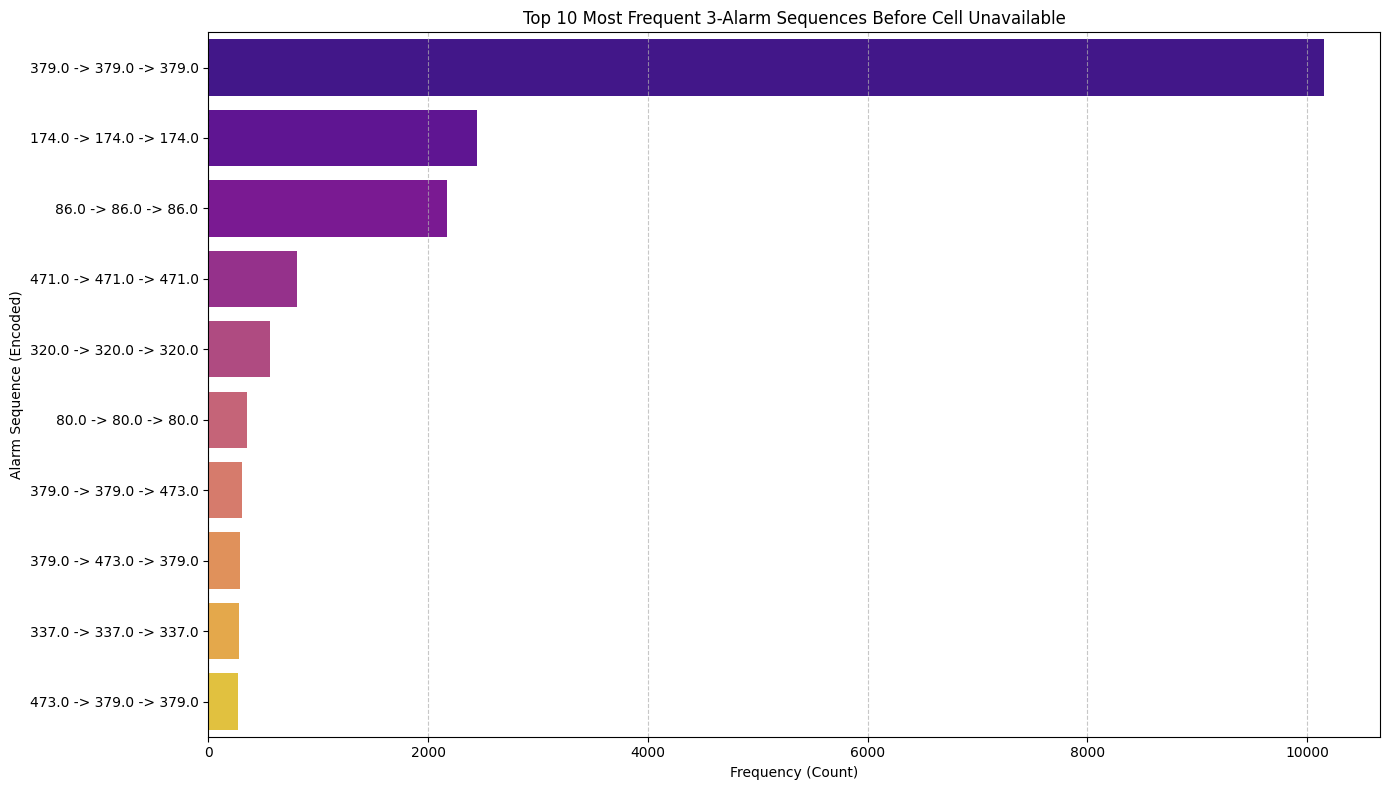


--- Analysis of 5 Alarm Sequence Before Cell Unavailable ---


,Sequence,Count,Percentage
0,379.0 -> 379.0 -> 379.0 -> 379.0 -> 379.0,8825,27.37
1,174.0 -> 174.0 -> 174.0 -> 174.0 -> 174.0,2083,6.46
2,86.0 -> 86.0 -> 86.0 -> 86.0 -> 86.0,1363,4.23
3,471.0 -> 471.0 -> 471.0 -> 471.0 -> 471.0,666,2.07
4,320.0 -> 320.0 -> 320.0 -> 320.0 -> 320.0,447,1.39
5,80.0 -> 80.0 -> 80.0 -> 80.0 -> 80.0,302,0.94
6,379.0 -> 379.0 -> 379.0 -> 379.0 -> 473.0,183,0.57
7,473.0 -> 379.0 -> 379.0 -> 379.0 -> 379.0,163,0.51
8,379.0 -> 379.0 -> 379.0 -> 473.0 -> 379.0,154,0.48
9,332.0 -> 332.0 -> 332.0 -> 332.0 -> 332.0,150,0.47


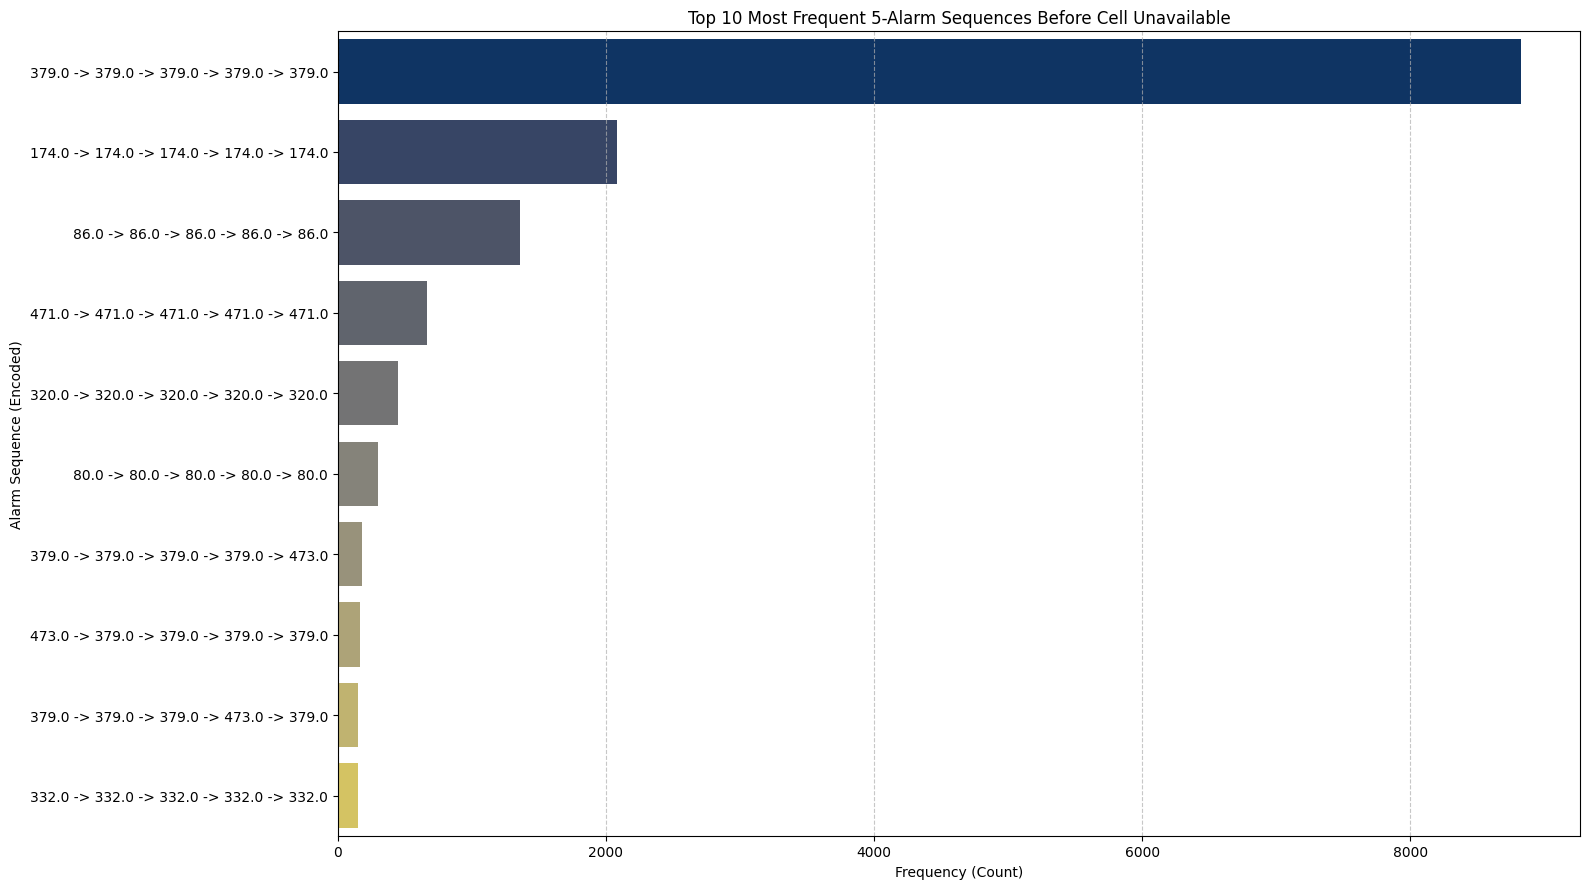

In [26]:
# Filter the DataFrame to include only 'Cell Unavailable' events (target == 1)
df_target_1 = df[df['target'] == 1].copy()

# Drop rows where previous alarms are NaN for a cleaner analysis of sequences
df_target_1.dropna(subset=['previous_alarm_1', 'previous_alarm_2', 'previous_alarm_3', 'previous_alarm_4', 'previous_alarm_5'], inplace=True)

print(f"Number of 'Cell Unavailable' events after dropping NaNs for previous alarms: {len(df_target_1)}")

# --- Previous Alarm (1 alarm before) ---
print("\n--- Analysis of 1 Alarm Before Cell Unavailable ---")
alarm_1_before = df_target_1['previous_alarm_1'].value_counts().reset_index()
alarm_1_before.columns = ['Previous_Alarm_1_Encoded', 'Count']
alarm_1_before['Percentage'] = (alarm_1_before['Count'] / alarm_1_before['Count'].sum() * 100).round(2)

display(alarm_1_before.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Previous_Alarm_1_Encoded', data=alarm_1_before.head(10), palette='viridis', hue='Previous_Alarm_1_Encoded', legend=False)
plt.title('Top 10 Most Frequent 1st Previous Alarms Before Cell Unavailable')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Previous 2 Alarm Sequence ---
print("\n--- Analysis of 2 Alarm Sequence Before Cell Unavailable ---")
df_target_1['Sequence_2_Alarms'] = df_target_1['previous_alarm_2'].astype(str) + ' -> ' + df_target_1['previous_alarm_1'].astype(str)
sequence_2_alarms = df_target_1['Sequence_2_Alarms'].value_counts().reset_index()
sequence_2_alarms.columns = ['Sequence', 'Count']
sequence_2_alarms['Percentage'] = (sequence_2_alarms['Count'] / sequence_2_alarms['Count'].sum() * 100).round(2)

display(sequence_2_alarms.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Sequence', data=sequence_2_alarms.head(10), palette='magma', hue='Sequence', legend=False)
plt.title('Top 10 Most Frequent 2-Alarm Sequences Before Cell Unavailable')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Sequence (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Previous 3 Alarm Sequence ---
print("\n--- Analysis of 3 Alarm Sequence Before Cell Unavailable ---")
df_target_1['Sequence_3_Alarms'] = df_target_1['previous_alarm_3'].astype(str) + ' -> ' + \
                                    df_target_1['previous_alarm_2'].astype(str) + ' -> ' + \
                                    df_target_1['previous_alarm_1'].astype(str)
sequence_3_alarms = df_target_1['Sequence_3_Alarms'].value_counts().reset_index()
sequence_3_alarms.columns = ['Sequence', 'Count']
sequence_3_alarms['Percentage'] = (sequence_3_alarms['Count'] / sequence_3_alarms['Count'].sum() * 100).round(2)

display(sequence_3_alarms.head(10))

plt.figure(figsize=(14, 8))
sns.barplot(x='Count', y='Sequence', data=sequence_3_alarms.head(10), palette='plasma', hue='Sequence', legend=False)
plt.title('Top 10 Most Frequent 3-Alarm Sequences Before Cell Unavailable')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Sequence (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Previous 5 Alarm Sequence ---
print("\n--- Analysis of 5 Alarm Sequence Before Cell Unavailable ---")
df_target_1['Sequence_5_Alarms'] = df_target_1['previous_alarm_5'].astype(str) + ' -> ' + \
                                    df_target_1['previous_alarm_4'].astype(str) + ' -> ' + \
                                    df_target_1['previous_alarm_3'].astype(str) + ' -> ' + \
                                    df_target_1['previous_alarm_2'].astype(str) + ' -> ' + \
                                    df_target_1['previous_alarm_1'].astype(str)
sequence_5_alarms = df_target_1['Sequence_5_Alarms'].value_counts().reset_index()
sequence_5_alarms.columns = ['Sequence', 'Count']
sequence_5_alarms['Percentage'] = (sequence_5_alarms['Count'] / sequence_5_alarms['Count'].sum() * 100).round(2)

display(sequence_5_alarms.head(10))

plt.figure(figsize=(16, 9))
sns.barplot(x='Count', y='Sequence', data=sequence_5_alarms.head(10), palette='cividis', hue='Sequence', legend=False)
plt.title('Top 10 Most Frequent 5-Alarm Sequences Before Cell Unavailable')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Sequence (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Interpretation

- The analysis of previous alarms and alarm sequences before 'Cell Unavailable' events provides crucial insights into recurring patterns. We can observe the most frequent individual alarms that immediately precede a 'Cell Unavailable' event, as well as common sequences of 2, 3, and 5 alarms.
- Identifying these patterns is vital for predictive maintenance and early warning systems. If specific alarm sequences consistently lead to 'Cell Unavailable', these can be flagged as high-risk indicators.
- Further investigation would involve mapping these encoded alarm IDs back to their original descriptive names to understand the physical or logical events they represent.

## SECTION 9: Historical Alarm Risk Analysis

### Objective
Calculate the conditional probability P(Cell Unavailable | Alarm) for every unique alarm to estimate how likely a 'Cell Unavailable' event occurs after a particular alarm, based on historical data. We will display the top 20 highest-risk and lowest-risk alarms and visualize them using horizontal bar charts.

--- Top 20 Highest-Risk Alarms (P(Cell Unavailable | Alarm)) ---


,P(No Cell Unavailable),P(Cell Unavailable)
previous_alarm_1,,
406.0,0.000000,1.000000
348.0,0.000000,1.000000
86.0,0.000000,1.000000
63.0,0.000000,1.000000
22.0,0.031250,0.968750
333.0,0.105263,0.894737
337.0,0.174925,0.825075
42.0,0.181818,0.818182
56.0,0.187500,0.812500


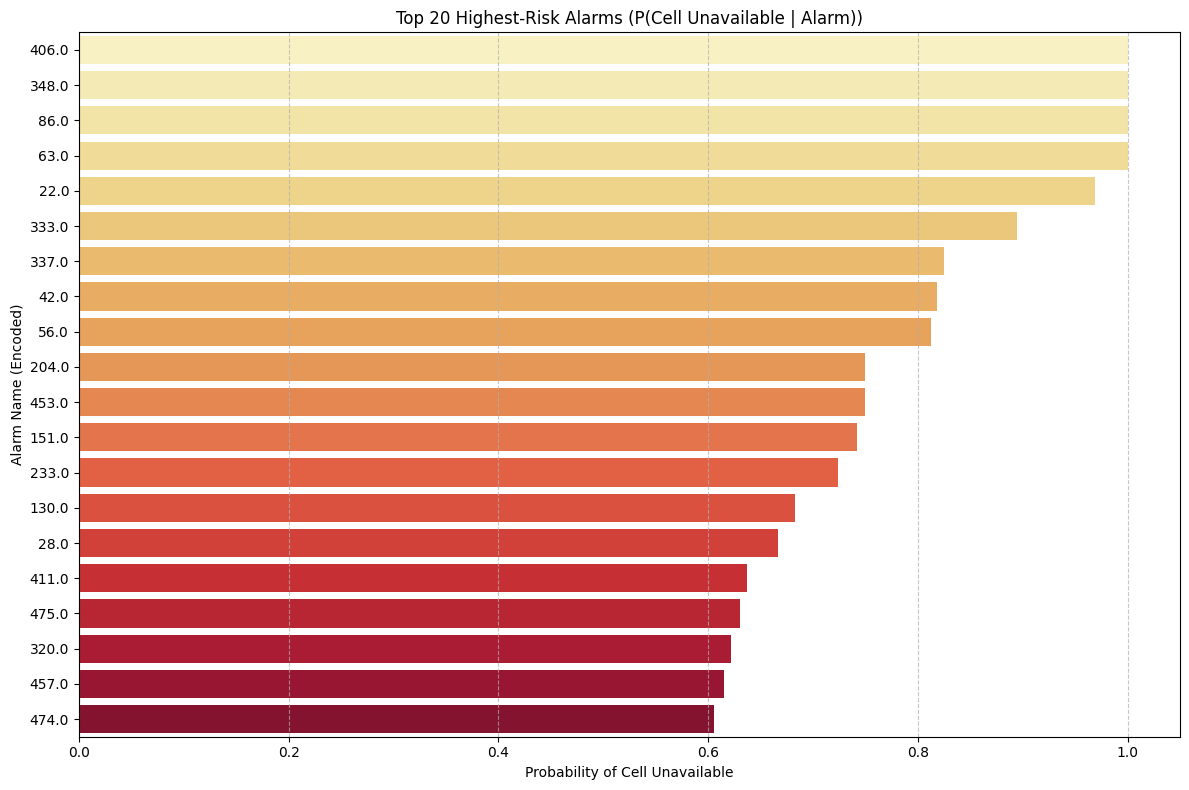


--- Top 20 Lowest-Risk Alarms (P(Cell Unavailable | Alarm)) ---


,P(No Cell Unavailable),P(Cell Unavailable)
previous_alarm_1,,
139.0,0.842424,0.157576
265.0,0.845132,0.154868
85.0,0.850900,0.149100
365.0,0.857143,0.142857
478.0,0.863248,0.136752
46.0,0.881579,0.118421
379.0,0.883622,0.116378
364.0,0.893668,0.106332
216.0,0.895833,0.104167


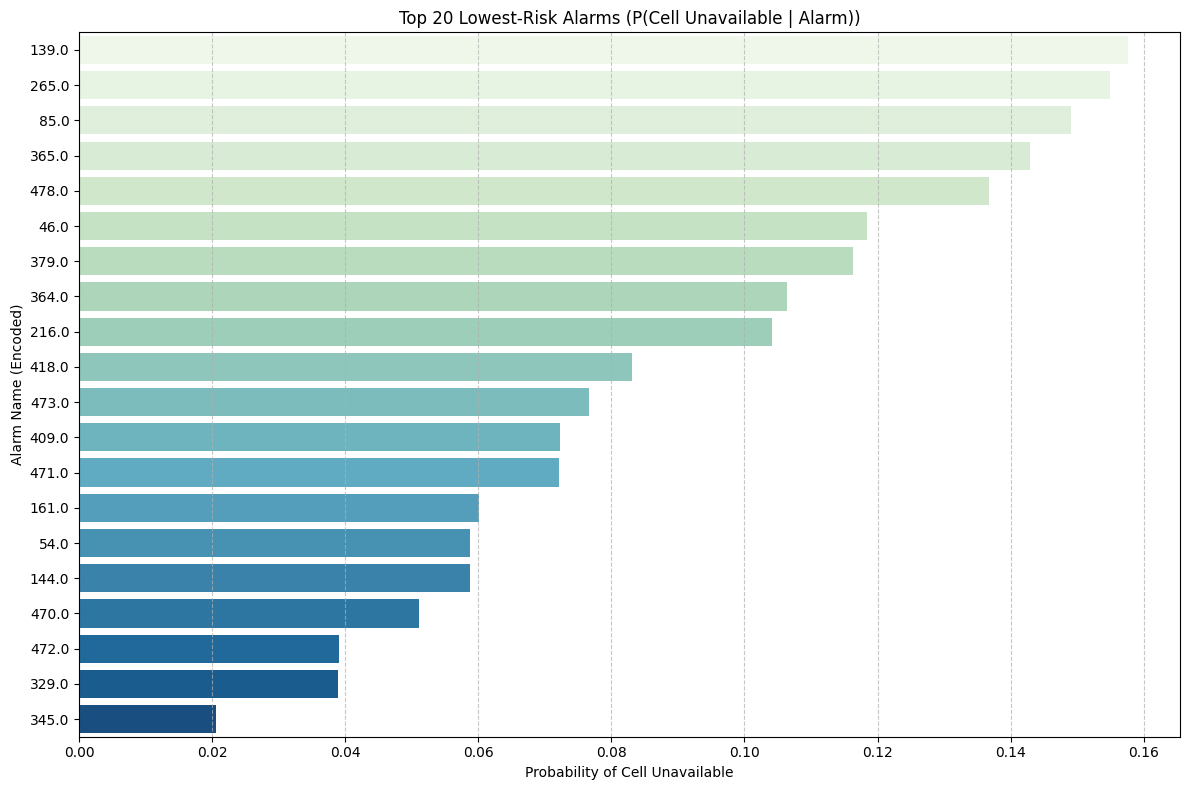

In [27]:
# Calculate P(Cell Unavailable | Alarm) for each alarm
# This means, for each unique alarm, what is the proportion of times it is followed by a 'Cell Unavailable' event.

# To simplify, we will consider `previous_alarm_1` as the 'alarm' that directly precedes a 'Cell Unavailable' event.
# We can expand this to other `previous_alarm_X` columns if needed, but for now, this provides a direct risk assessment.

alarm_risk = df.groupby('previous_alarm_1')['target'].value_counts(normalize=True).unstack().fillna(0)

# Rename columns for clarity
alarm_risk.columns = ['P(No Cell Unavailable)', 'P(Cell Unavailable)']

# Sort by 'P(Cell Unavailable)' to find highest and lowest risk alarms
alarm_risk_sorted = alarm_risk.sort_values(by='P(Cell Unavailable)', ascending=False)

print("--- Top 20 Highest-Risk Alarms (P(Cell Unavailable | Alarm)) ---")
highest_risk_alarms = alarm_risk_sorted.head(20)
display(highest_risk_alarms)

plt.figure(figsize=(12, 8))
sns.barplot(x='P(Cell Unavailable)', y=highest_risk_alarms.index.astype(str), data=highest_risk_alarms, palette='YlOrRd', hue=highest_risk_alarms.index.astype(str), legend=False)
plt.title('Top 20 Highest-Risk Alarms (P(Cell Unavailable | Alarm))')
plt.xlabel('Probability of Cell Unavailable')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Top 20 Lowest-Risk Alarms (P(Cell Unavailable | Alarm)) ---")
# Filter out alarms with 0 probability if they are too many, or show those with very low but non-zero probability
lowest_risk_alarms = alarm_risk_sorted[alarm_risk_sorted['P(Cell Unavailable)'] > 0].tail(20) # Showing non-zero probabilities

# If there are many alarms with 0 probability, we might want to display a different set or explain this.
# For now, we take the last 20 with some non-zero probability, or if all are zero, the last 20 overall.
if len(lowest_risk_alarms) == 0: # If all remaining have 0 probability, just take the last 20 from the full sorted list
    lowest_risk_alarms = alarm_risk_sorted.tail(20)

display(lowest_risk_alarms)

plt.figure(figsize=(12, 8))
sns.barplot(x='P(Cell Unavailable)', y=lowest_risk_alarms.index.astype(str), data=lowest_risk_alarms, palette='GnBu', hue=lowest_risk_alarms.index.astype(str), legend=False)
plt.title('Top 20 Lowest-Risk Alarms (P(Cell Unavailable | Alarm))')
plt.xlabel('Probability of Cell Unavailable')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Interpretation

- The **Top 20 Highest-Risk Alarms** are those most frequently followed by a 'Cell Unavailable' event. These alarms are critical indicators and should be prioritized for immediate attention by telecom engineers. Their occurrence suggests a high probability of network service disruption.
- The **Top 20 Lowest-Risk Alarms** (with non-zero probability of 'Cell Unavailable') are less likely to lead to a 'Cell Unavailable' event. While not as critical as the high-risk alarms, understanding these can help in resource allocation and avoiding unnecessary interventions for less severe issues.
- This analysis provides a data-driven approach to prioritize alarms based on their historical impact on service availability.

## SECTION 10: Tower-Level Analysis

### Objective
Analyze tower-level data using `enodeb_id` to identify:

*   Towers with the highest number of alarms.
*   Towers with the highest number of 'Cell Unavailable' events.
*   Average alarms per tower.
*   Average 'Cell Unavailable' events per tower.

Suitable visualizations will be created, and the findings will be interpreted.

--- Towers with Highest Number of Alarms ---


,count
enodeb_id,
1364,2166
1845,1971
2095,1811
2181,1726
2109,1634
1305,1609
2101,1561
1408,1544
1690,1395


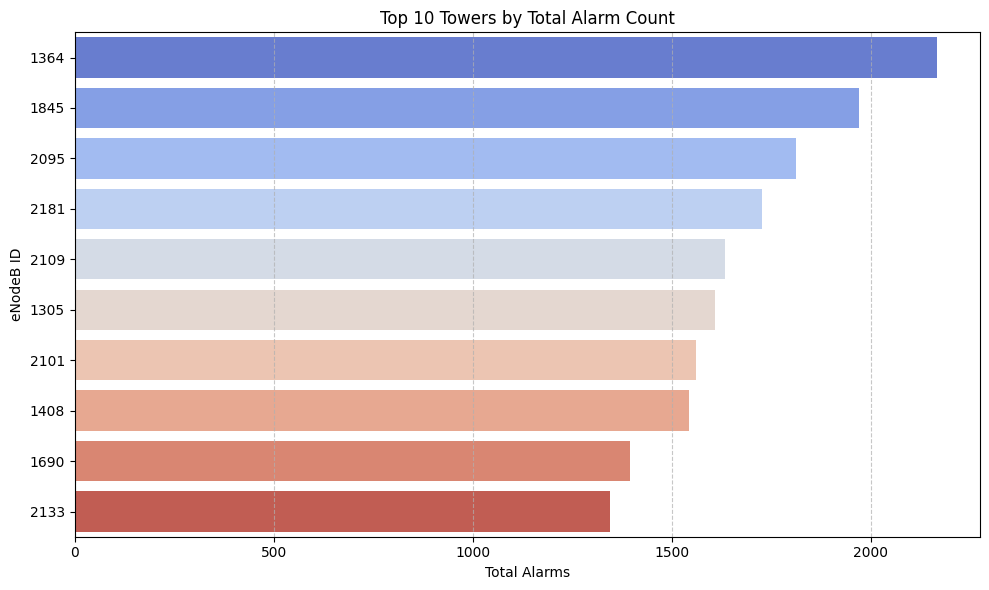


--- Towers with Highest Number of Cell Unavailable Events ---


,count
enodeb_id,
1845,1541
2095,1364
2321,1198
1690,998
2101,925
1148,823
1240,812
1313,770
1575,716


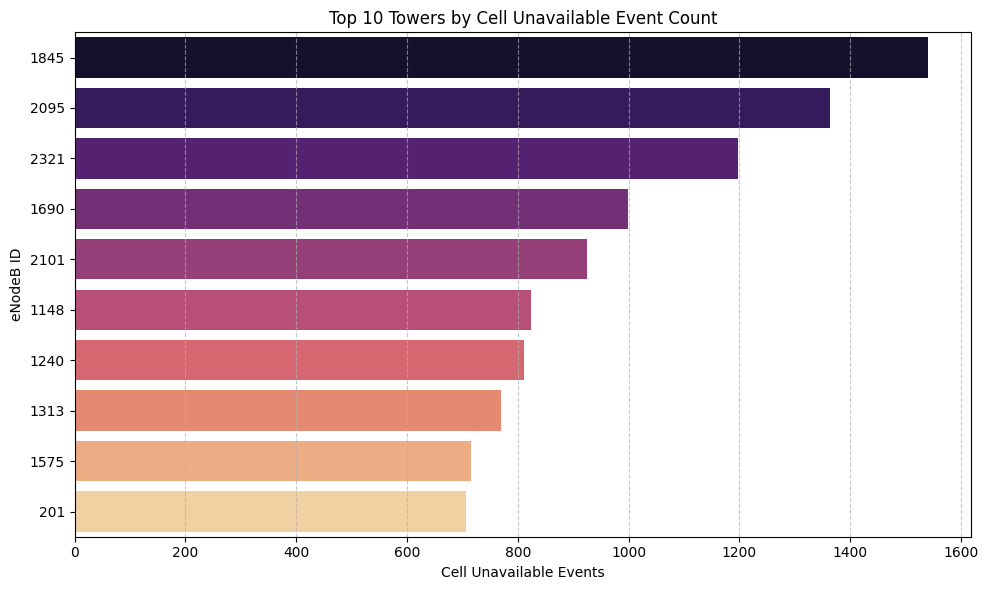


--- Average Alarms Per Tower ---
Average number of alarms per tower: 206.84

--- Average Cell Unavailable Events Per Tower ---
Average number of Cell Unavailable events per tower (for towers with at least one event): 257.98
Average number of Cell Unavailable events per tower (across all towers): 34.71


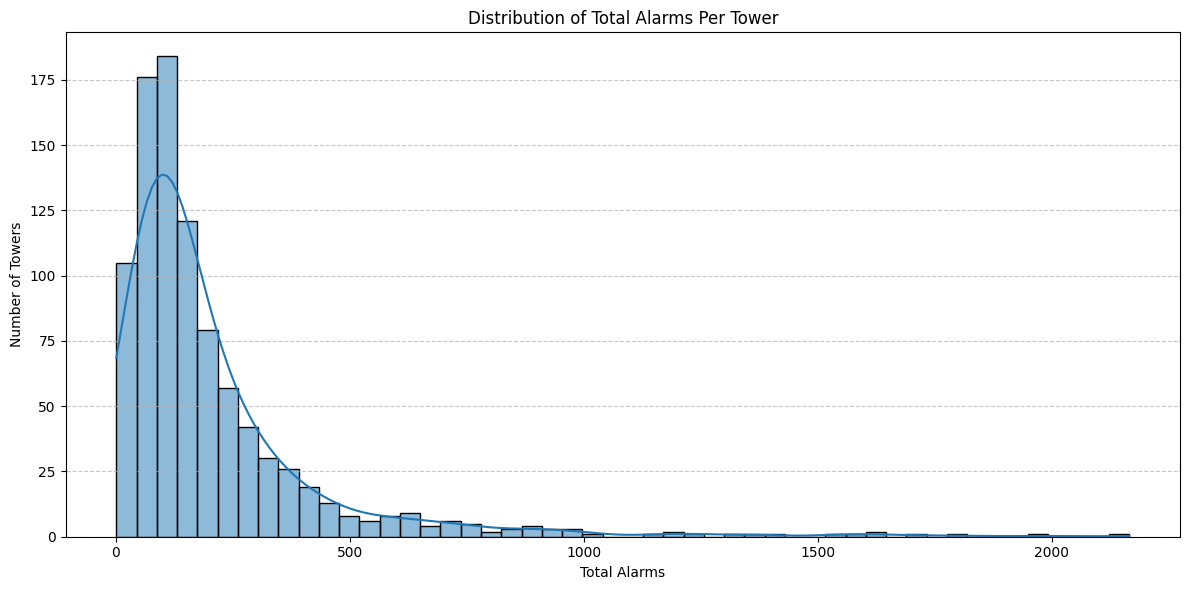

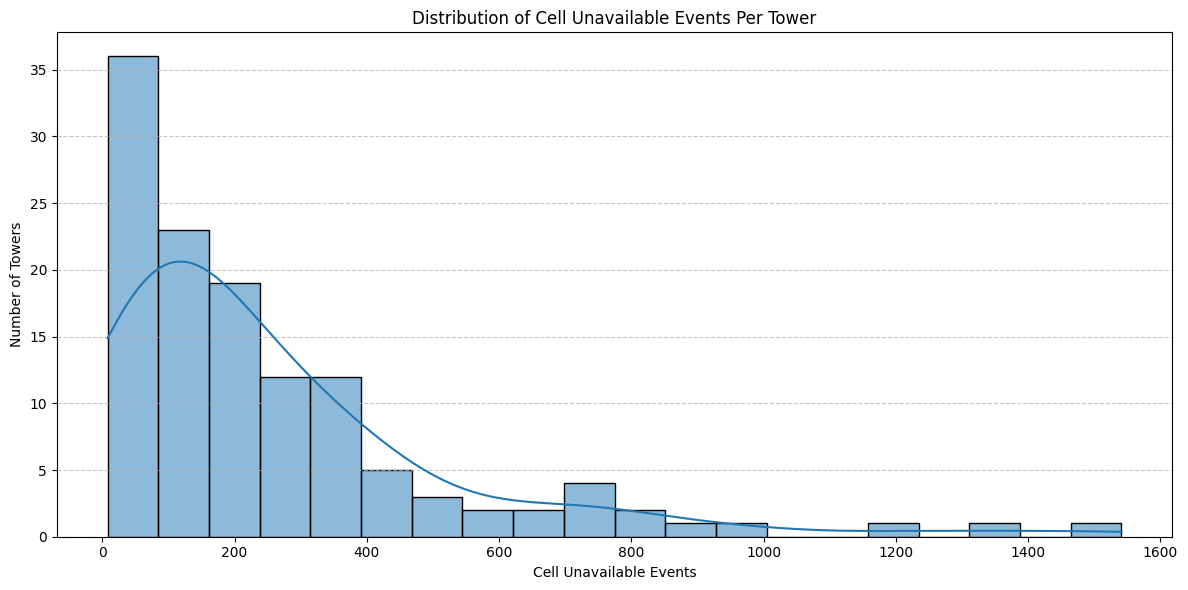

In [28]:
# 1. Towers with highest number of alarms
print("--- Towers with Highest Number of Alarms ---")
alarms_per_tower = df['enodeb_id'].value_counts().sort_values(ascending=False)
display(alarms_per_tower.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=alarms_per_tower.head(10).values, y=alarms_per_tower.head(10).index.astype(str), palette='coolwarm', hue=alarms_per_tower.head(10).index.astype(str), legend=False)
plt.title('Top 10 Towers by Total Alarm Count')
plt.xlabel('Total Alarms')
plt.ylabel('eNodeB ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Towers with highest number of Cell Unavailable events
print("\n--- Towers with Highest Number of Cell Unavailable Events ---")
cell_unavailable_per_tower = df[df['target'] == 1]['enodeb_id'].value_counts().sort_values(ascending=False)
display(cell_unavailable_per_tower.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=cell_unavailable_per_tower.head(10).values, y=cell_unavailable_per_tower.head(10).index.astype(str), palette='magma', hue=cell_unavailable_per_tower.head(10).index.astype(str), legend=False)
plt.title('Top 10 Towers by Cell Unavailable Event Count')
plt.xlabel('Cell Unavailable Events')
plt.ylabel('eNodeB ID')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Average alarms per tower
print("\n--- Average Alarms Per Tower ---")
average_alarms_per_tower = alarms_per_tower.mean()
print(f"Average number of alarms per tower: {average_alarms_per_tower:.2f}")

# 4. Average Cell Unavailable events per tower
print("\n--- Average Cell Unavailable Events Per Tower ---")
average_cell_unavailable_per_tower = cell_unavailable_per_tower.mean()
print(f"Average number of Cell Unavailable events per tower (for towers with at least one event): {average_cell_unavailable_per_tower:.2f}")

# For a more comprehensive average, consider all unique towers, even those with 0 cell unavailable events.
all_unique_towers = df['enodeb_id'].nunique()
total_cell_unavailable_events = df['target'].sum()
average_cell_unavailable_all_towers = total_cell_unavailable_events / all_unique_towers
print(f"Average number of Cell Unavailable events per tower (across all towers): {average_cell_unavailable_all_towers:.2f}")

# Visualize distribution of alarms and cell unavailable events per tower (optional, for deeper insight)
plt.figure(figsize=(12, 6))
sns.histplot(alarms_per_tower, bins=50, kde=True)
plt.title('Distribution of Total Alarms Per Tower')
plt.xlabel('Total Alarms')
plt.ylabel('Number of Towers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(cell_unavailable_per_tower, bins=20, kde=True)
plt.title('Distribution of Cell Unavailable Events Per Tower')
plt.xlabel('Cell Unavailable Events')
plt.ylabel('Number of Towers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Interpretation

- The **Tower-Level Analysis** highlights specific `enodeb_id`s that are experiencing the most alarms and, more critically, the most 'Cell Unavailable' events. These 'hotspot' towers require immediate attention and potentially proactive maintenance to prevent service disruptions.
- The average figures provide a baseline for comparison. Towers significantly exceeding the average alarm or 'Cell Unavailable' count are outliers that warrant deeper investigation into their operational conditions, hardware health, or environmental factors.
- Understanding which towers are most problematic allows for targeted resource allocation, optimizing maintenance schedules, and improving overall network reliability.

## SECTION 11: Alarm Category Contribution

### Objective
Create alarm categories (e.g., Hardware, Transmission, Power, License, Communication, Environmental, Other) and assign each alarm to one category. Then, calculate:

*   Number of alarms in each category.
*   Number of 'Cell Unavailable' events preceded by each category.
*   Percentage contribution of each category.

Visualize these findings using pie charts and horizontal bar charts and interpret the results.

--- Number of Alarms in Each Category ---


,Category,Count,Percentage
0,Hardware,116511,60.63
1,Other,24379,12.69
2,Transmission,21812,11.35
3,Power,15795,8.22
4,License,5046,2.63
5,Communication,4453,2.32
6,Environmental,4158,2.16


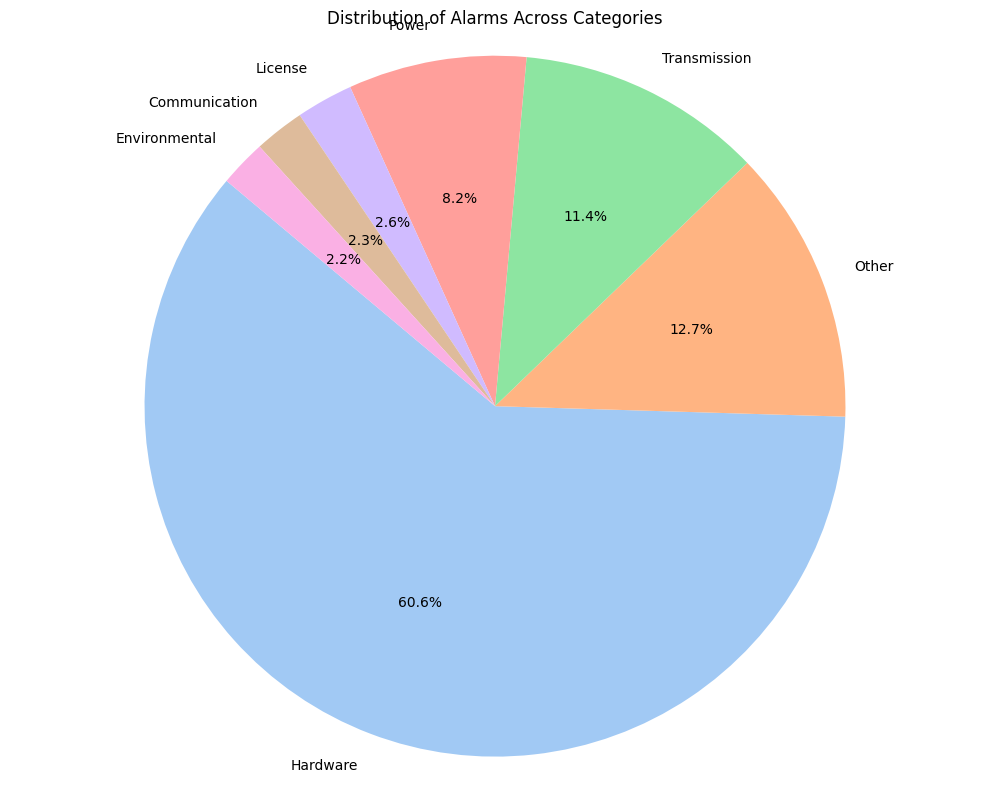


--- Cell Unavailable Events Preceded by Each Category ---


,Category,Cell_Unavailable_Count,Percentage_of_CU
0,Hardware,17010,52.75
1,Other,7966,24.70
2,License,2820,8.74
3,Transmission,2158,6.69
4,Power,1426,4.42
5,Environmental,641,1.99
6,Communication,226,0.70


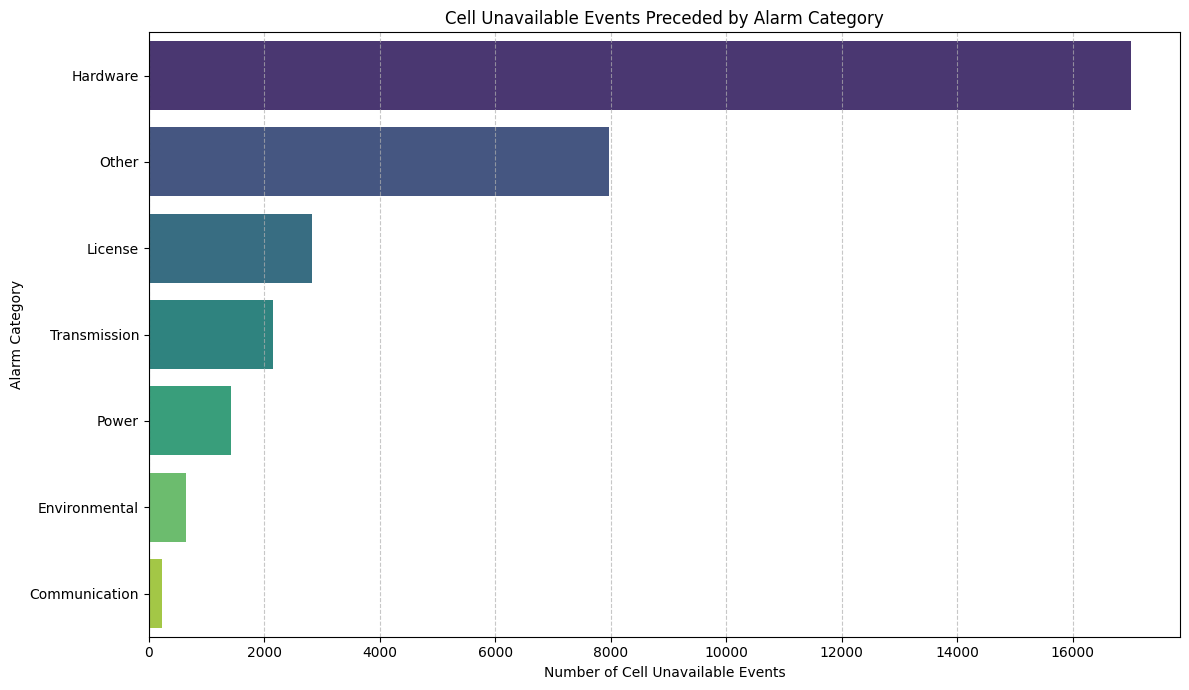

In [29]:
# NOTE: This section requires a mapping from 'alarm_name_encoded' to actual alarm names or categories.
# Since we only have encoded values, I will create a hypothetical mapping for demonstration purposes.
# In a real-world scenario, this mapping would come from a data dictionary provided by domain experts.

# Hypothetical mapping for demonstration. In practice, this would be comprehensive.
# Mapping a few encoded alarm IDs to categories.
alarm_category_mapping = {
    379: 'Hardware', # Example: Common hardware fault
    471: 'Transmission', # Example: Link down
    473: 'Power',      # Example: Power failure
    174: 'License',    # Example: License expiration
    470: 'Communication', # Example: Signaling issue
    265: 'Environmental', # Example: Temperature alarm
    86: 'Hardware', # Another hardware type
    318: 'Transmission', # Another transmission type
    319: 'Power', # Another power type
    24: 'Other', # General category
    # Add more mappings as per your domain knowledge
}

# Create a default category for alarms not explicitly mapped
def get_category(alarm_encoded_id):
    return alarm_category_mapping.get(alarm_encoded_id, 'Other')

df['alarm_category'] = df['alarm_name_encoded'].apply(get_category)

# 1. Number of alarms in each category
print("--- Number of Alarms in Each Category ---")
alarms_in_category = df['alarm_category'].value_counts().reset_index()
alarms_in_category.columns = ['Category', 'Count']
alarms_in_category['Percentage'] = (alarms_in_category['Count'] / alarms_in_category['Count'].sum() * 100).round(2)
display(alarms_in_category)

plt.figure(figsize=(10, 8))
plt.pie(alarms_in_category['Count'], labels=alarms_in_category['Category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Alarms Across Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

# 2. Number of Cell Unavailable events preceded by each category
# We consider an event 'preceded' by a category if `previous_alarm_1` falls into that category.
# This can be refined to consider a sequence if necessary.

print("\n--- Cell Unavailable Events Preceded by Each Category ---")
df_target_1_categorized = df[df['target'] == 1].copy()
df_target_1_categorized['previous_alarm_category'] = df_target_1_categorized['previous_alarm_1'].apply(get_category)

cell_unavailable_by_category = df_target_1_categorized['previous_alarm_category'].value_counts().reset_index()
cell_unavailable_by_category.columns = ['Category', 'Cell_Unavailable_Count']
cell_unavailable_by_category['Percentage_of_CU'] = (cell_unavailable_by_category['Cell_Unavailable_Count'] / cell_unavailable_by_category['Cell_Unavailable_Count'].sum() * 100).round(2)
display(cell_unavailable_by_category)

plt.figure(figsize=(12, 7))
sns.barplot(x='Cell_Unavailable_Count', y='Category', data=cell_unavailable_by_category, palette='viridis', hue='Category', legend=False)
plt.title('Cell Unavailable Events Preceded by Alarm Category')
plt.xlabel('Number of Cell Unavailable Events')
plt.ylabel('Alarm Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Percentage contribution of each category to ALL alarms (already calculated in alarms_in_category)
# 4. Percentage contribution of each category to Cell Unavailable events (already calculated in cell_unavailable_by_category)


### Interpretation

- The **Alarm Category Contribution** analysis reveals which types of alarms are most prevalent and, more importantly, which categories are most frequently associated with 'Cell Unavailable' events.
- The pie chart for alarm distribution shows the general prevalence of different alarm types. A large slice for 'Other' might suggest a need to expand and refine the categorization scheme.
- The bar chart for 'Cell Unavailable' events by category highlights the critical areas. If, for instance, 'Power' or 'Transmission' alarms frequently precede 'Cell Unavailable' events, it indicates vulnerabilities in these critical infrastructure components.
- This categorization helps in a higher-level understanding of network health, guiding strategic investments and policy changes in network management and maintenance.

## SECTION 12: Engineered Feature Analysis

### Objective
Analyze the engineered features created during feature engineering, including `sequence_length`, `alarm_repeat_count`, `previous_cell_unavailable_count`, and `alarm_duration_minutes`. We will display histograms, boxplots, and summary statistics for these features and interpret which features appear useful for predicting 'Cell Unavailable'.


--- Analysis of Engineered Feature: sequence_length ---
Summary Statistics:


,sequence_length
count,192153.000000
mean,246.948525
std,309.382731
min,0.000000
25%,55.000000
50%,132.000000
75%,307.000000
max,2165.000000


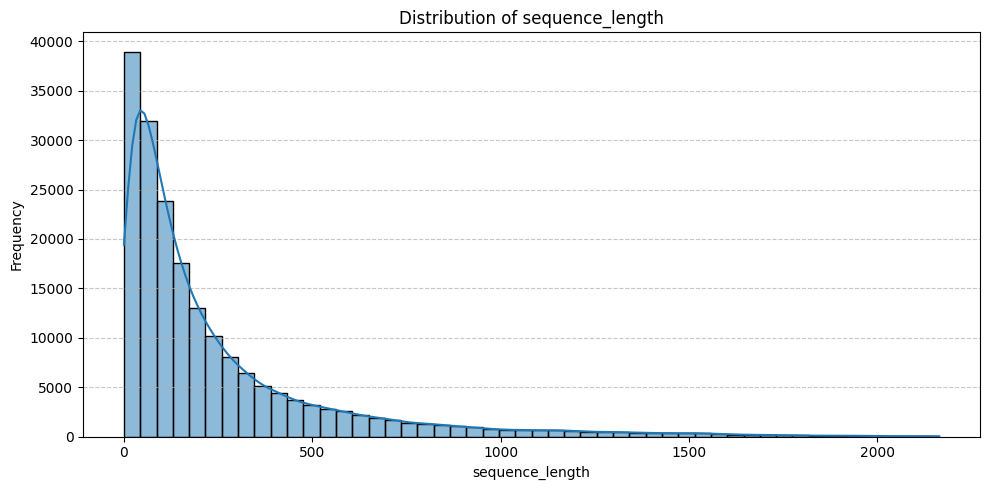

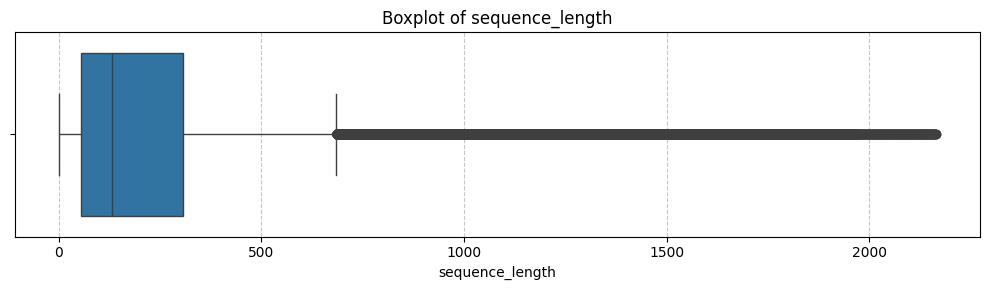

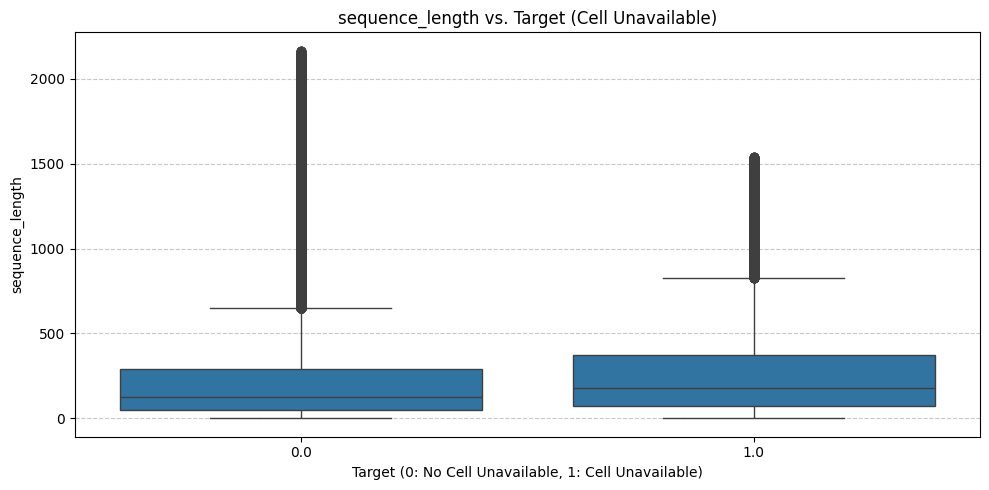


--- Analysis of Engineered Feature: alarm_repeat_count ---
Summary Statistics:


,alarm_repeat_count
count,192153.000000
mean,138.110958
std,210.037753
min,0.000000
25%,17.000000
50%,58.000000
75%,160.000000
max,1824.000000


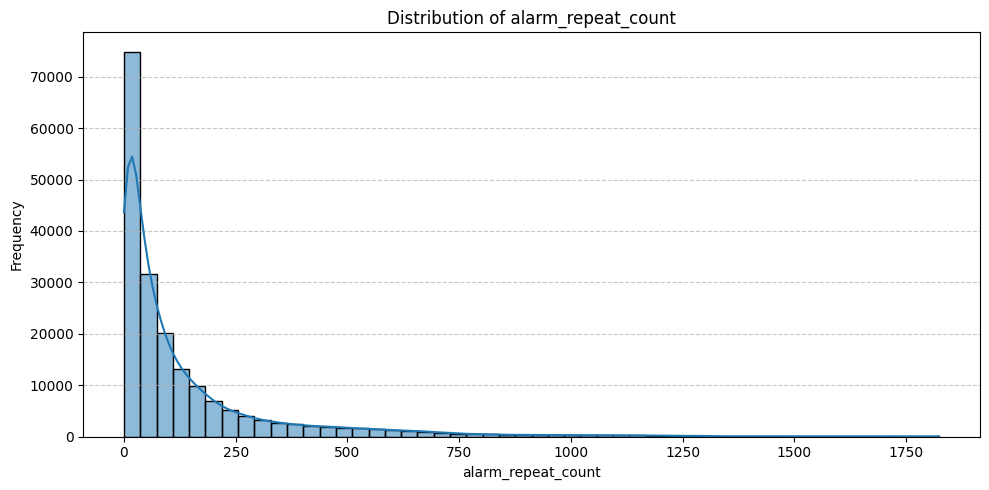

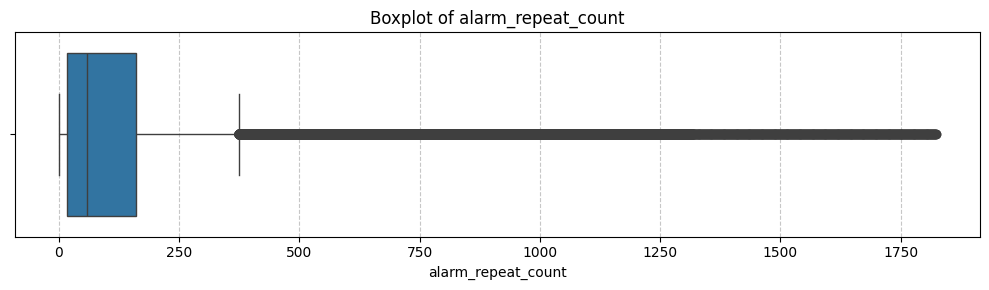

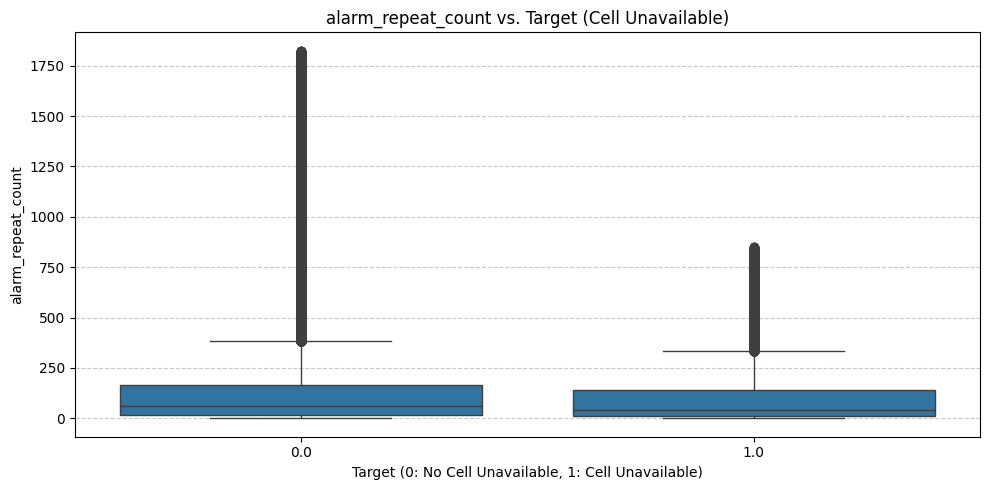


--- Analysis of Engineered Feature: previous_cell_unavailable_count ---
Summary Statistics:


,previous_cell_unavailable_count
count,192153.000000
mean,9.016752
std,49.155438
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,570.000000


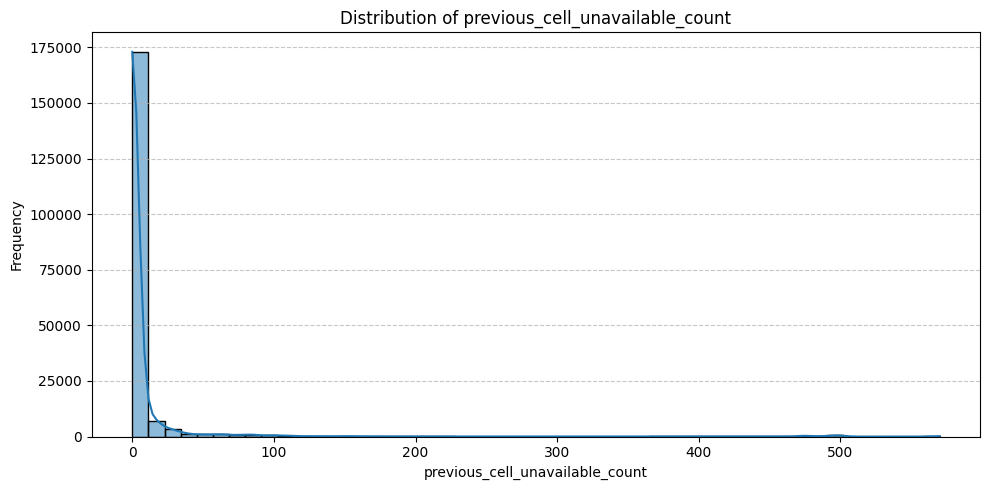

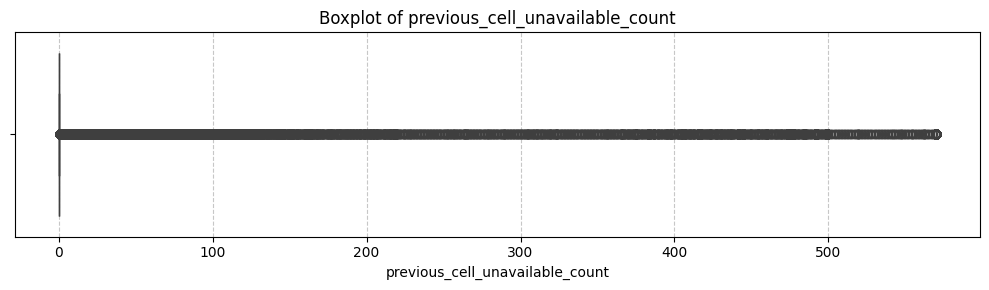

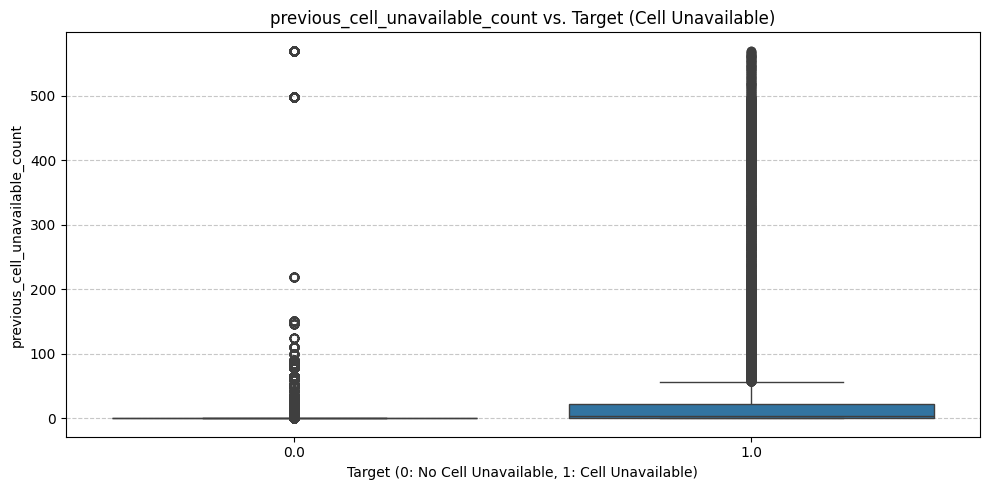


--- Analysis of Engineered Feature: alarm_duration_minutes ---
Summary Statistics:


,alarm_duration_minutes
count,192154.000000
mean,314.356818
std,1275.005965
min,0.000000
25%,2.266667
50%,6.800000
75%,113.900000
max,44345.800000


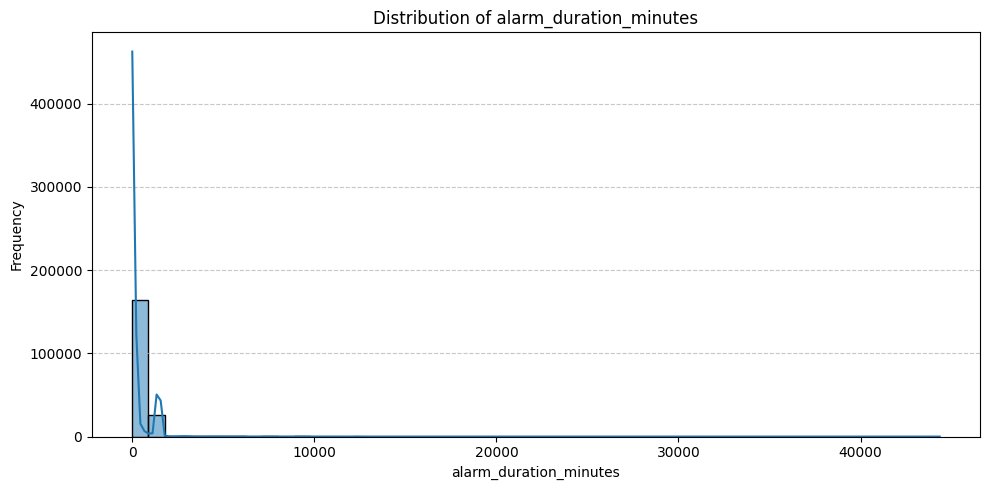

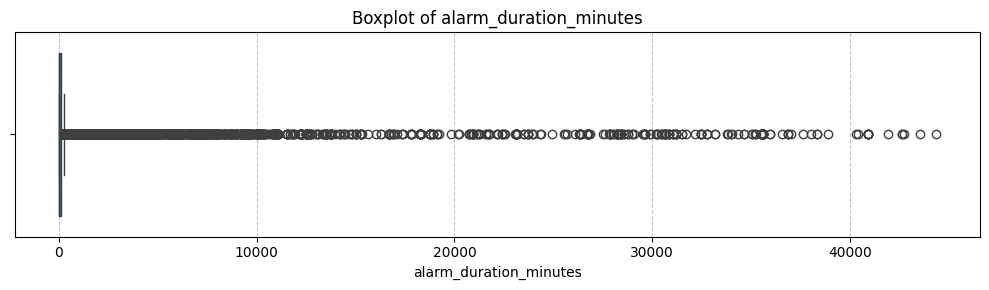

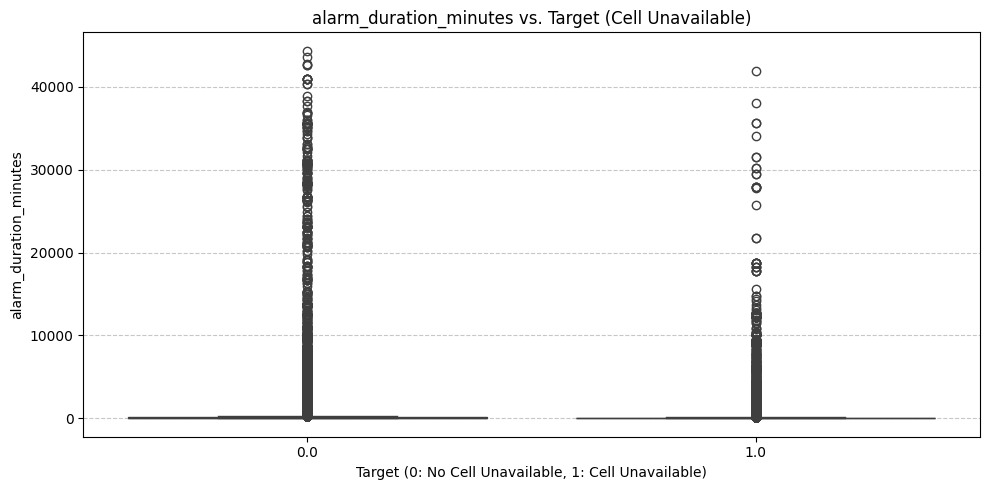

In [30]:
engineered_features = [
    'sequence_length',
    'alarm_repeat_count',
    'previous_cell_unavailable_count',
    'alarm_duration_minutes'
]

for feature in engineered_features:
    print(f"\n--- Analysis of Engineered Feature: {feature} ---")

    # Display Summary Statistics
    print("Summary Statistics:")
    display(df[feature].describe())

    # Plot Histogram
    plt.figure(figsize=(10, 5))
    sns.histplot(df[feature].dropna(), bins=50, kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Plot Boxplot
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df[feature].dropna())
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Also, check the relationship with the target variable
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='target', y=feature, data=df.dropna(subset=[feature, 'target']))
    plt.title(f'{feature} vs. Target (Cell Unavailable)')
    plt.xlabel('Target (0: No Cell Unavailable, 1: Cell Unavailable)')
    plt.ylabel(feature)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


### Interpretation

- The analysis of **Engineered Features** provides insights into their distributions and their potential relationship with the 'Cell Unavailable' target variable.
- **`sequence_length`**: Histograms and boxplots reveal the typical number of alarms in a sequence. If there's a noticeable difference in `sequence_length` distributions between 'Cell Unavailable' and 'No Cell Unavailable' events, it suggests this feature is important.
- **`alarm_repeat_count`**: This feature indicates how often a specific alarm has occurred. A higher repeat count before a 'Cell Unavailable' event might signal persistent issues, making it a strong predictor.
- **`previous_cell_unavailable_count`**: This is a direct indicator of past instability. A higher count strongly suggests a tower's proneness to 'Cell Unavailable' events.
- **`alarm_duration_minutes`**: The duration of alarms can be a critical factor. Longer alarm durations might be more indicative of severe underlying issues leading to 'Cell Unavailable'.
- Features showing distinct distributions or different mean/median values for `target = 0` vs. `target = 1` are likely to be highly informative for the predictive model.

## SECTION 13: Correlation Analysis

### Objective
Generate a correlation heatmap using only numerical features. We will highlight strong positive and negative correlations, explain that encoded categorical variables should be interpreted carefully, and identify any highly correlated engineered features.

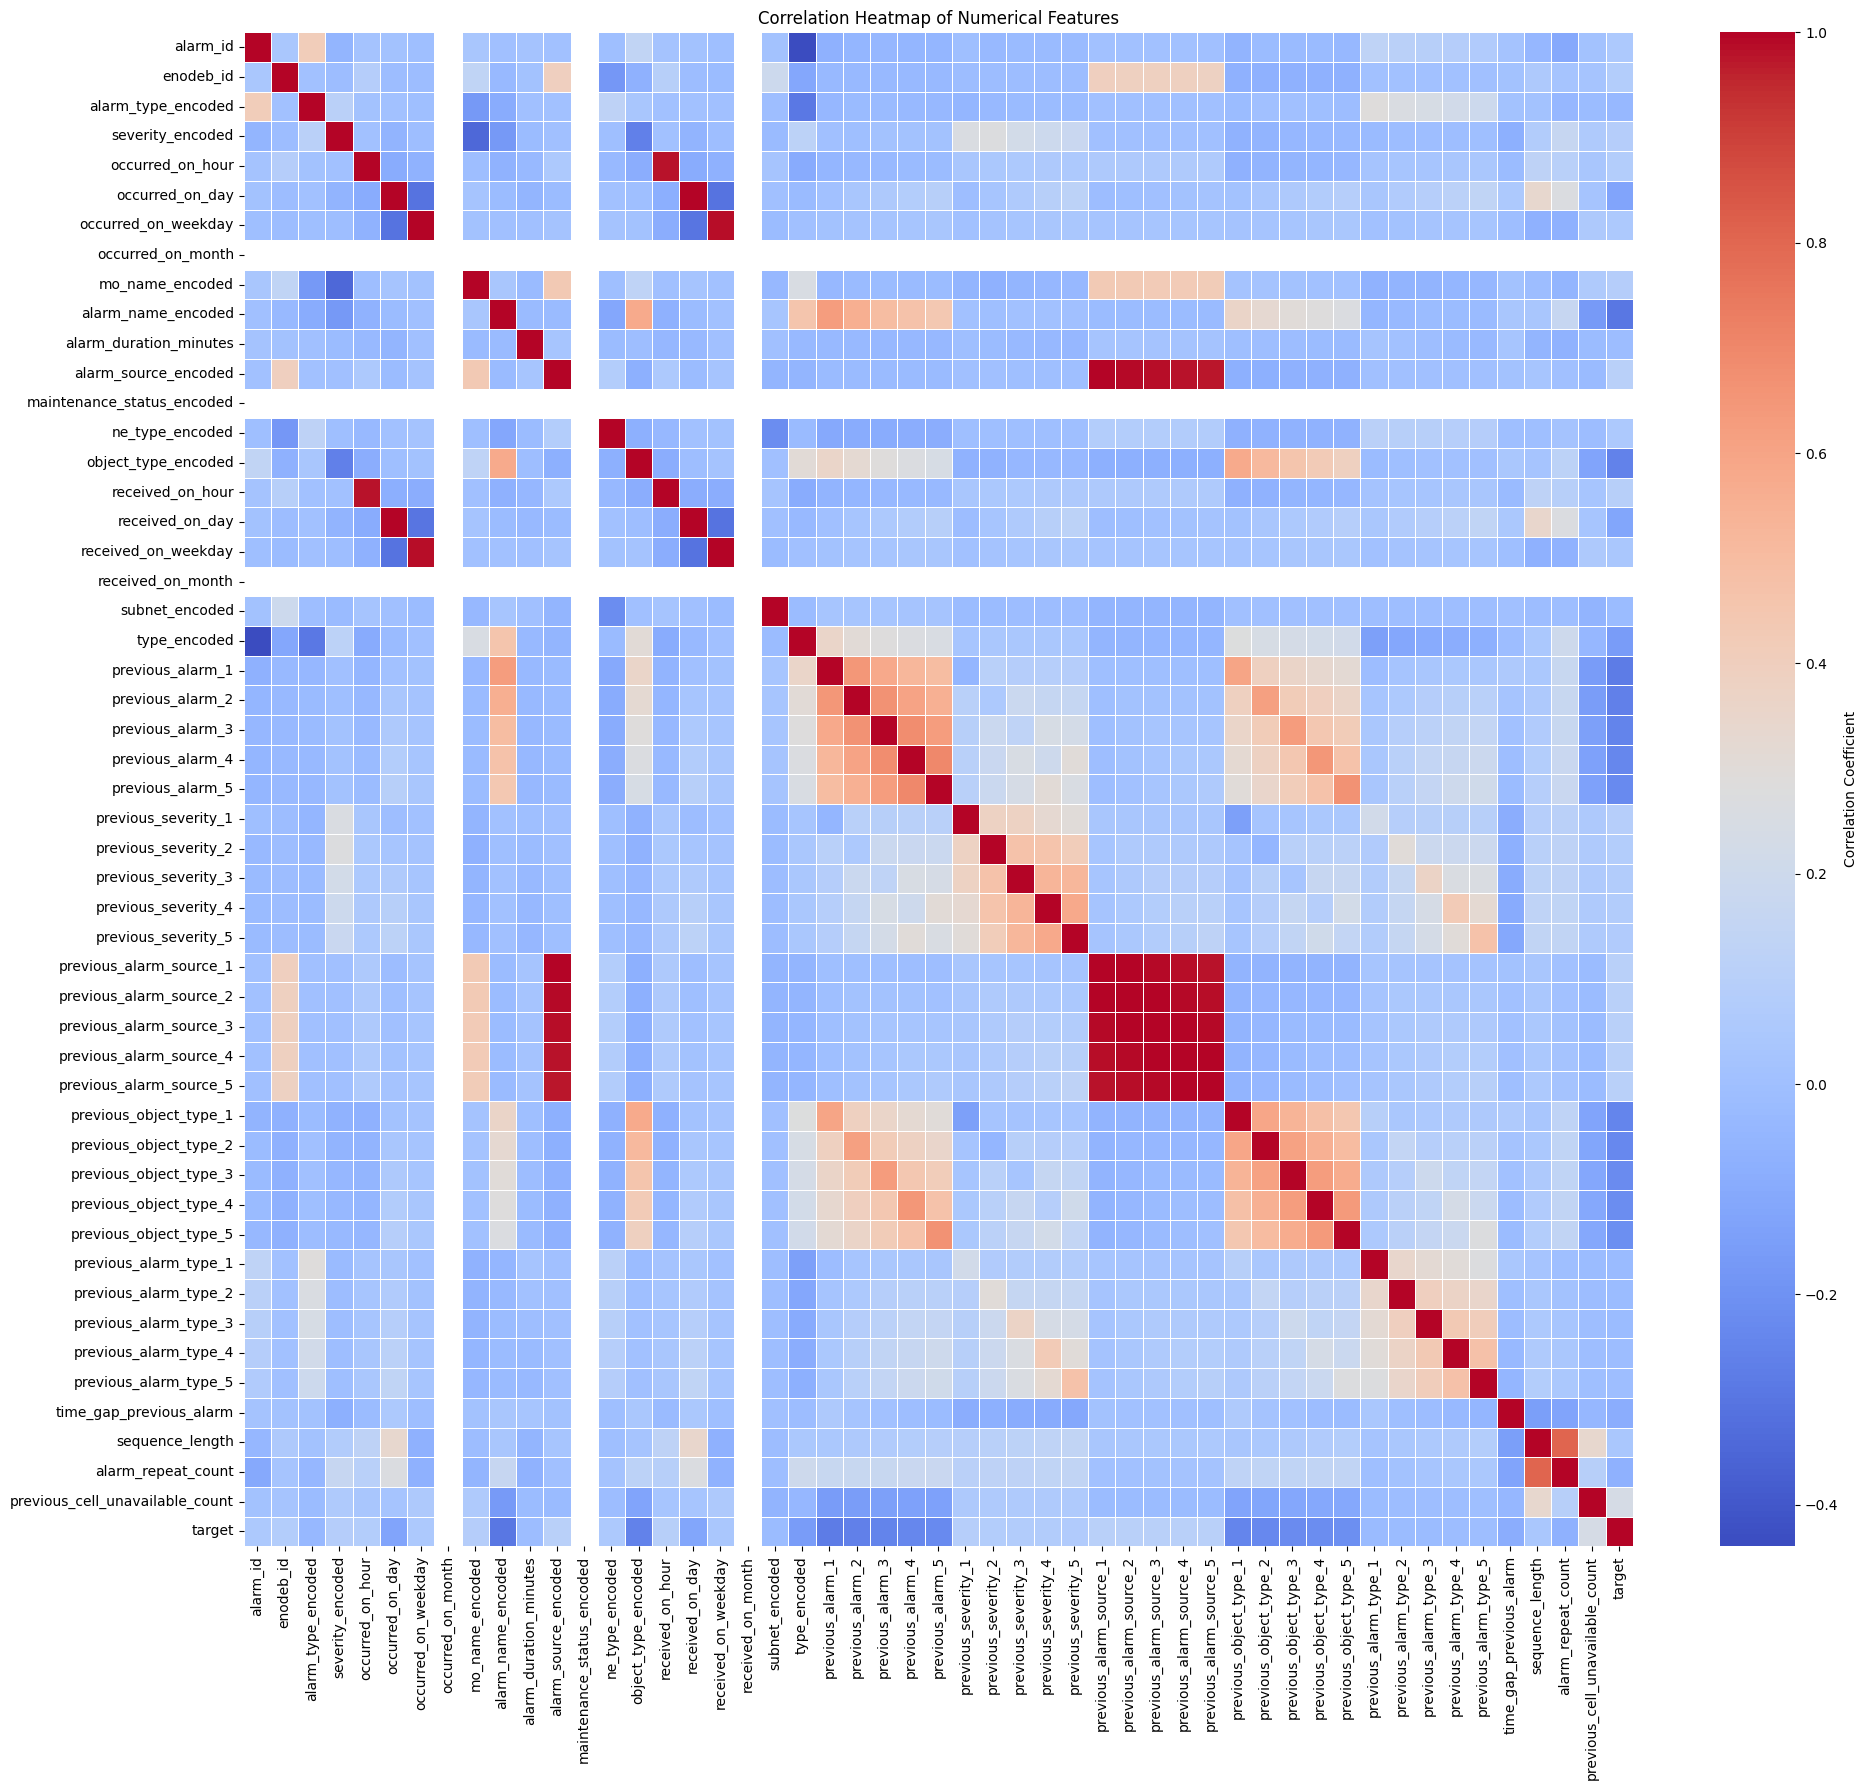


--- Correlations with Target Variable ---


,target
target,1.000000
previous_cell_unavailable_count,0.239679
previous_alarm_source_5,0.104317
previous_alarm_source_4,0.104036
previous_alarm_source_3,0.103752
previous_alarm_source_2,0.103464
previous_alarm_source_1,0.103178
alarm_source_encoded,0.100742
received_on_hour,0.096559
previous_severity_1,0.091309



--- Highly Correlated Engineered Features (with each other) ---


,,0
sequence_length,sequence_length,1.000000
alarm_repeat_count,alarm_repeat_count,1.000000
alarm_duration_minutes,alarm_duration_minutes,1.000000
previous_cell_unavailable_count,previous_cell_unavailable_count,1.000000
alarm_repeat_count,sequence_length,0.805168


In [31]:
# Select only numerical columns for correlation analysis
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Numerical Features')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n--- Correlations with Target Variable ---")
target_correlations = correlation_matrix['target'].sort_values(ascending=False)
display(target_correlations)

print("\n--- Highly Correlated Engineered Features (with each other) ---")
# Focus on engineered features and their correlations among themselves and with other features
engineered_features = [
    'sequence_length',
    'alarm_repeat_count',
    'previous_cell_unavailable_count',
    'alarm_duration_minutes'
]

engineered_corr = correlation_matrix.loc[engineered_features, engineered_features]

# Mask the upper triangle to avoid duplicate values and self-correlation
mask = np.triu(np.ones_like(engineered_corr, dtype=bool))
np.fill_diagonal(mask, False) # Do not mask diagonal for self-correlation (which is 1)

highly_correlated_engineered_features = engineered_corr.mask(mask).stack().sort_values(ascending=False).abs()
display(highly_correlated_engineered_features[highly_correlated_engineered_features > 0.7]) # Threshold for 'highly correlated'


### Interpretation

- The **Correlation Heatmap** visualizes the linear relationships between all numerical features.
- **Strong positive correlations** (values close to 1) indicate that two features tend to increase or decrease together. For example, if `alarm_duration_minutes` is strongly positively correlated with `target`, it means longer alarms are more likely to result in 'Cell Unavailable'.
- **Strong negative correlations** (values close to -1) mean that as one feature increases, the other tends to decrease.
- **Correlations with 'target'**: Observing which features have the strongest positive or negative correlation with the `target` variable is crucial for feature selection in machine learning models. These features are likely strong predictors.
- **Encoded Categorical Variables**: It's important to remember that `encoded` categorical variables (like `alarm_name_encoded` or `severity_encoded`) are numerical representations of categories. Their correlation with other variables should be interpreted as a relationship between their assigned numerical order and the other variable, not necessarily a linear relationship in the traditional sense of continuous variables.
- **Highly Correlated Engineered Features**: If engineered features are highly correlated with each other, it might suggest multicollinearity. While this isn't always problematic, it can sometimes indicate redundancy, and feature selection might be considered to use only one of the highly correlated features to avoid inflating model variance or making interpretation difficult.

## SECTION 9: Conditional Probability Analysis (Most Important)

### Objective
To discover how the probability of a future 'Cell Unavailable' event changes as additional alarms occur in the same eNodeB. This analysis mirrors the concept that the final machine learning model will learn and will be performed separately for each tower (`enodeb_id`), while using historical data from all towers to calculate overall probabilities.


### Part 1 - Single Alarm Probability

For every unique alarm, we will calculate `P(Cell Unavailable | Alarm)`. This means, given that Alarm A has occurred (as `previous_alarm_1`), what is the historical probability that the same tower eventually experiences a 'Cell Unavailable' event? We will display the top 20 highest and lowest probability alarms and visualize them using horizontal bar charts.


--- Part 1: Single Alarm Probability ---

Top 20 Alarms with Highest P(Cell Unavailable | Alarm):


,P(No CU | Alarm),P(CU | Alarm)
previous_alarm_1,,
406.0,0.000000,1.000000
348.0,0.000000,1.000000
86.0,0.000000,1.000000
63.0,0.000000,1.000000
22.0,0.031250,0.968750
333.0,0.105263,0.894737
337.0,0.174925,0.825075
42.0,0.181818,0.818182
56.0,0.187500,0.812500


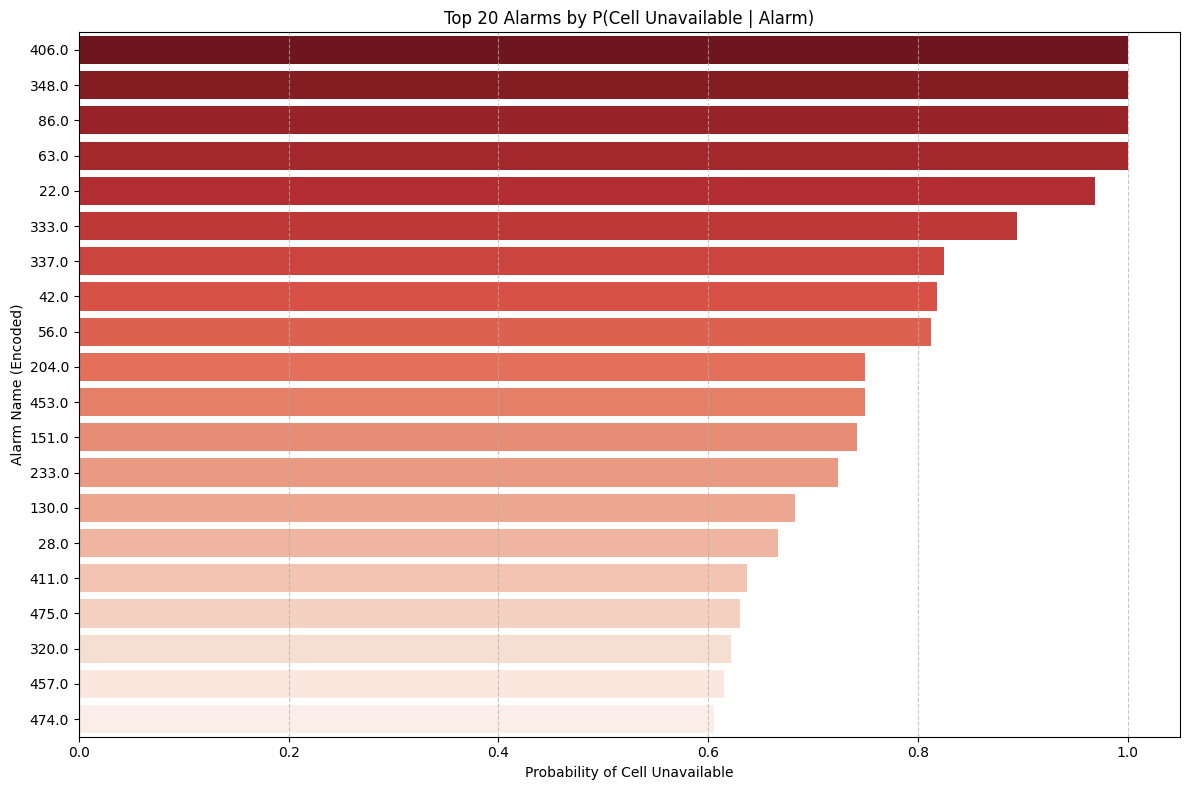


Top 20 Alarms with Lowest P(Cell Unavailable | Alarm) (excluding 0% probability where possible):


,P(No CU | Alarm),P(CU | Alarm)
previous_alarm_1,,
139.0,0.842424,0.157576
265.0,0.845132,0.154868
85.0,0.850900,0.149100
365.0,0.857143,0.142857
478.0,0.863248,0.136752
46.0,0.881579,0.118421
379.0,0.883622,0.116378
364.0,0.893668,0.106332
216.0,0.895833,0.104167


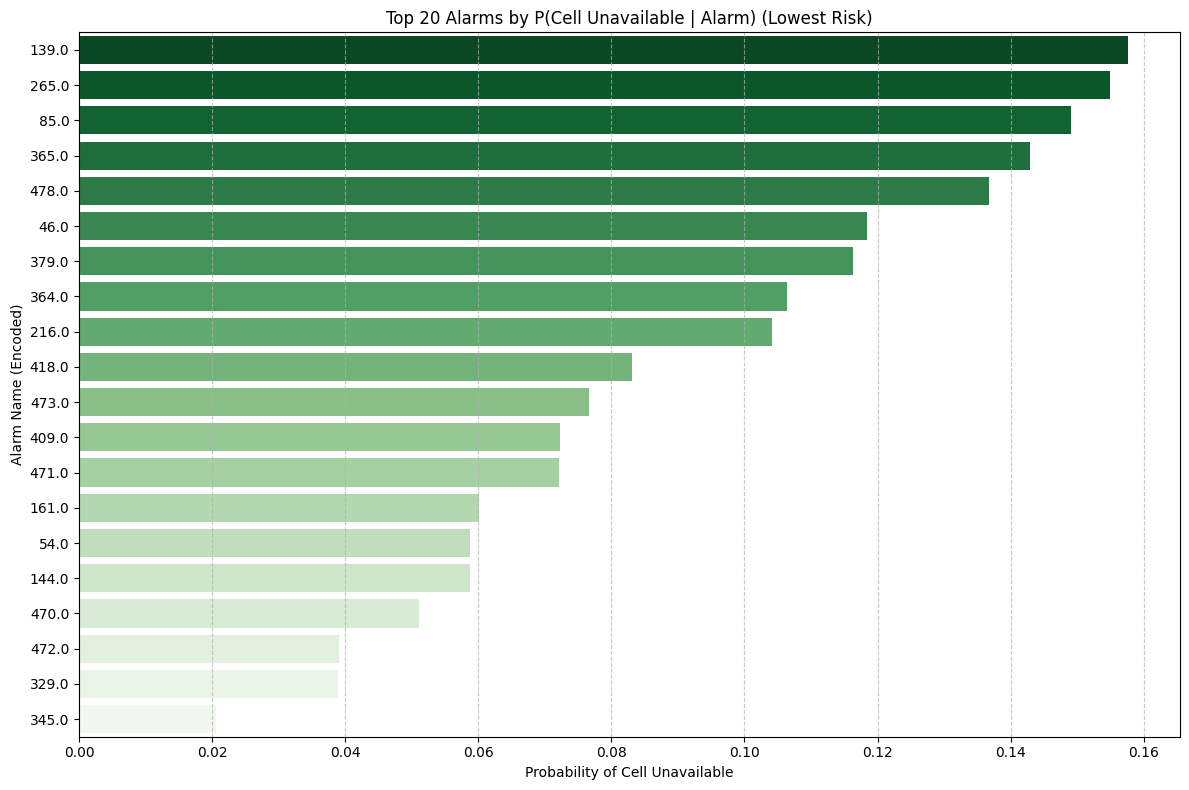

In [32]:
print("--- Part 1: Single Alarm Probability ---")

# Calculate P(Cell Unavailable | previous_alarm_1) for each unique alarm
# This is a re-calculation from Section 9 (Historical Alarm Risk Analysis), but it's important to keep the sections modular.

# Group by 'previous_alarm_1' and 'target', then calculate normalized counts.
# Unstack to get 'target=0' and 'target=1' as columns.
# Fill NaN values with 0, as some alarms might not have both target outcomes.
alarm_risk_single = df.groupby('previous_alarm_1')['target'].value_counts(normalize=True).unstack().fillna(0)

# Rename columns for clarity: P(target=0 | alarm) and P(target=1 | alarm)
alarm_risk_single.columns = ['P(No CU | Alarm)', 'P(CU | Alarm)']

# Sort by P(CU | Alarm) to identify highest and lowest risk alarms
alarm_risk_single_sorted = alarm_risk_single.sort_values(by='P(CU | Alarm)', ascending=False)

print("\nTop 20 Alarms with Highest P(Cell Unavailable | Alarm):")
highest_risk_single = alarm_risk_single_sorted.head(20)
display(highest_risk_single)

plt.figure(figsize=(12, 8))
sns.barplot(x='P(CU | Alarm)', y=highest_risk_single.index.astype(str), data=highest_risk_single, palette='Reds_r', hue=highest_risk_single.index.astype(str), legend=False)
plt.title('Top 20 Alarms by P(Cell Unavailable | Alarm)')
plt.xlabel('Probability of Cell Unavailable')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nTop 20 Alarms with Lowest P(Cell Unavailable | Alarm) (excluding 0% probability where possible):")
# Filter for alarms where P(CU | Alarm) is not 0, then take the bottom 20
lowest_risk_single = alarm_risk_single_sorted[alarm_risk_single_sorted['P(CU | Alarm)'] > 0].tail(20)

# If all remaining have 0 probability, just take the last 20 overall.
if len(lowest_risk_single) == 0:
    lowest_risk_single = alarm_risk_single_sorted.tail(20)
display(lowest_risk_single)

plt.figure(figsize=(12, 8))
sns.barplot(x='P(CU | Alarm)', y=lowest_risk_single.index.astype(str), data=lowest_risk_single, palette='Greens_r', hue=lowest_risk_single.index.astype(str), legend=False)
plt.title('Top 20 Alarms by P(Cell Unavailable | Alarm) (Lowest Risk)')
plt.xlabel('Probability of Cell Unavailable')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Part 2 - Two Alarm Sequence Probability

We will create alarm sequences using consecutive alarms (`previous_alarm_2` followed by `previous_alarm_1`) within the same eNodeB. For these sequences, we will calculate `P(Cell Unavailable | Alarm A → Alarm B)`. The most common alarm pairs, their historical probabilities, and the highest-risk pairs will be displayed, with the top 20 sequences visualized.


--- Part 2: Two Alarm Sequence Probability ---

Top 20 Highest-Risk Two-Alarm Sequences (P(Cell Unavailable | Sequence)):


,P(No CU | Seq),P(CU | Seq)
Alarm_Sequence_2,,
86.0 -> 471.0,0.0,1.0
86.0 -> 457.0,0.0,1.0
86.0 -> 45.0,0.0,1.0
86.0 -> 418.0,0.0,1.0
86.0 -> 412.0,0.0,1.0
86.0 -> 411.0,0.0,1.0
86.0 -> 409.0,0.0,1.0
86.0 -> 347.0,0.0,1.0
86.0 -> 333.0,0.0,1.0


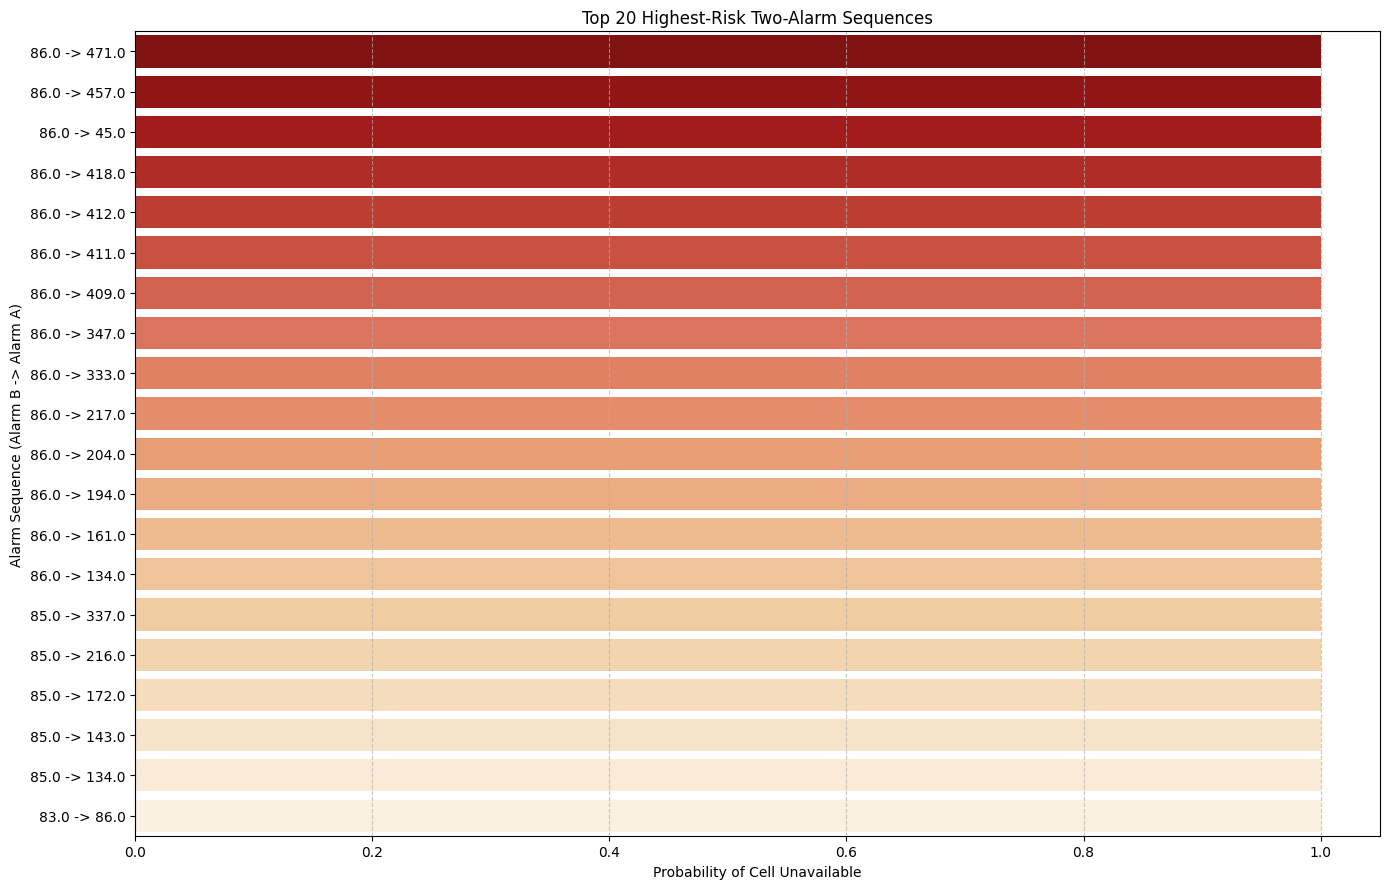


Top 20 Most Common Two-Alarm Sequences (by Occurrence Count):


,Occurrence Count
Alarm_Sequence_2,
379.0 -> 379.0,90777
471.0 -> 471.0,13809
379.0 -> 473.0,8176
473.0 -> 379.0,7745
174.0 -> 174.0,4642
379.0 -> 471.0,4265
471.0 -> 379.0,4205
86.0 -> 86.0,2881
473.0 -> 473.0,2678


In [33]:
print("--- Part 2: Two Alarm Sequence Probability ---")

# Ensure `previous_alarm_1` and `previous_alarm_2` are treated as the sequence leading to the 'target'
# Drop rows where either `previous_alarm_1` or `previous_alarm_2` is NaN to form valid sequences.
# We are considering a sequence of (Alarm B -> Alarm A) where Alarm A is the immediate predecessor to the target.
# So, the sequence is `previous_alarm_2` followed by `previous_alarm_1`.

df_seq_2 = df.dropna(subset=['previous_alarm_1', 'previous_alarm_2', 'target']).copy()
df_seq_2['Alarm_Sequence_2'] = df_seq_2['previous_alarm_2'].astype(str) + ' -> ' + df_seq_2['previous_alarm_1'].astype(str)

# Calculate P(Cell Unavailable | Alarm_Sequence_2)
seq_2_risk = df_seq_2.groupby('Alarm_Sequence_2')['target'].value_counts(normalize=True).unstack().fillna(0)
seq_2_risk.columns = ['P(No CU | Seq)', 'P(CU | Seq)']

# Sort by P(CU | Seq) to find highest risk sequences
seq_2_risk_sorted = seq_2_risk.sort_values(by='P(CU | Seq)', ascending=False)

print("\nTop 20 Highest-Risk Two-Alarm Sequences (P(Cell Unavailable | Sequence)):")
highest_risk_seq_2 = seq_2_risk_sorted.head(20)
display(highest_risk_seq_2)

plt.figure(figsize=(14, 9))
sns.barplot(x='P(CU | Seq)', y=highest_risk_seq_2.index, data=highest_risk_seq_2, palette='OrRd_r', hue=highest_risk_seq_2.index, legend=False)
plt.title('Top 20 Highest-Risk Two-Alarm Sequences')
plt.xlabel('Probability of Cell Unavailable')
plt.ylabel('Alarm Sequence (Alarm B -> Alarm A)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Also show most common alarm pairs (based on frequency, not necessarily risk)
print("\nTop 20 Most Common Two-Alarm Sequences (by Occurrence Count):")
most_common_seq_2 = df_seq_2['Alarm_Sequence_2'].value_counts().head(20)
display(most_common_seq_2.to_frame(name='Occurrence Count'))


### Part 3 - Three Alarm Sequence Probability

We will create consecutive three-alarm sequences (`previous_alarm_3` → `previous_alarm_2` → `previous_alarm_1`). For these sequences, we will calculate `P(Cell Unavailable | Alarm A → Alarm B → Alarm C)`. We will display the highest-risk three-alarm sequences, their occurrence counts, and their historical probabilities of 'Cell Unavailable'.


--- Part 3: Three Alarm Sequence Probability ---

Top 20 Highest-Risk Three-Alarm Sequences (P(Cell Unavailable | Sequence) and Occurrence Count):


,P(No CU | Seq),P(CU | Seq),Occurrence_Count
Alarm_Sequence_3,,,
-1.0 -> -1.0 -> 151.0,0.0,1.0,1
86.0 -> 86.0 -> 67.0,0.0,1.0,7
-1.0 -> -1.0 -> 161.0,0.0,1.0,1
-1.0 -> -1.0 -> 22.0,0.0,1.0,1
320.0 -> 337.0 -> 319.0,0.0,1.0,1
320.0 -> 337.0 -> 320.0,0.0,1.0,1
320.0 -> 337.0 -> 337.0,0.0,1.0,4
320.0 -> 337.0 -> 412.0,0.0,1.0,1
320.0 -> 337.0 -> 83.0,0.0,1.0,1


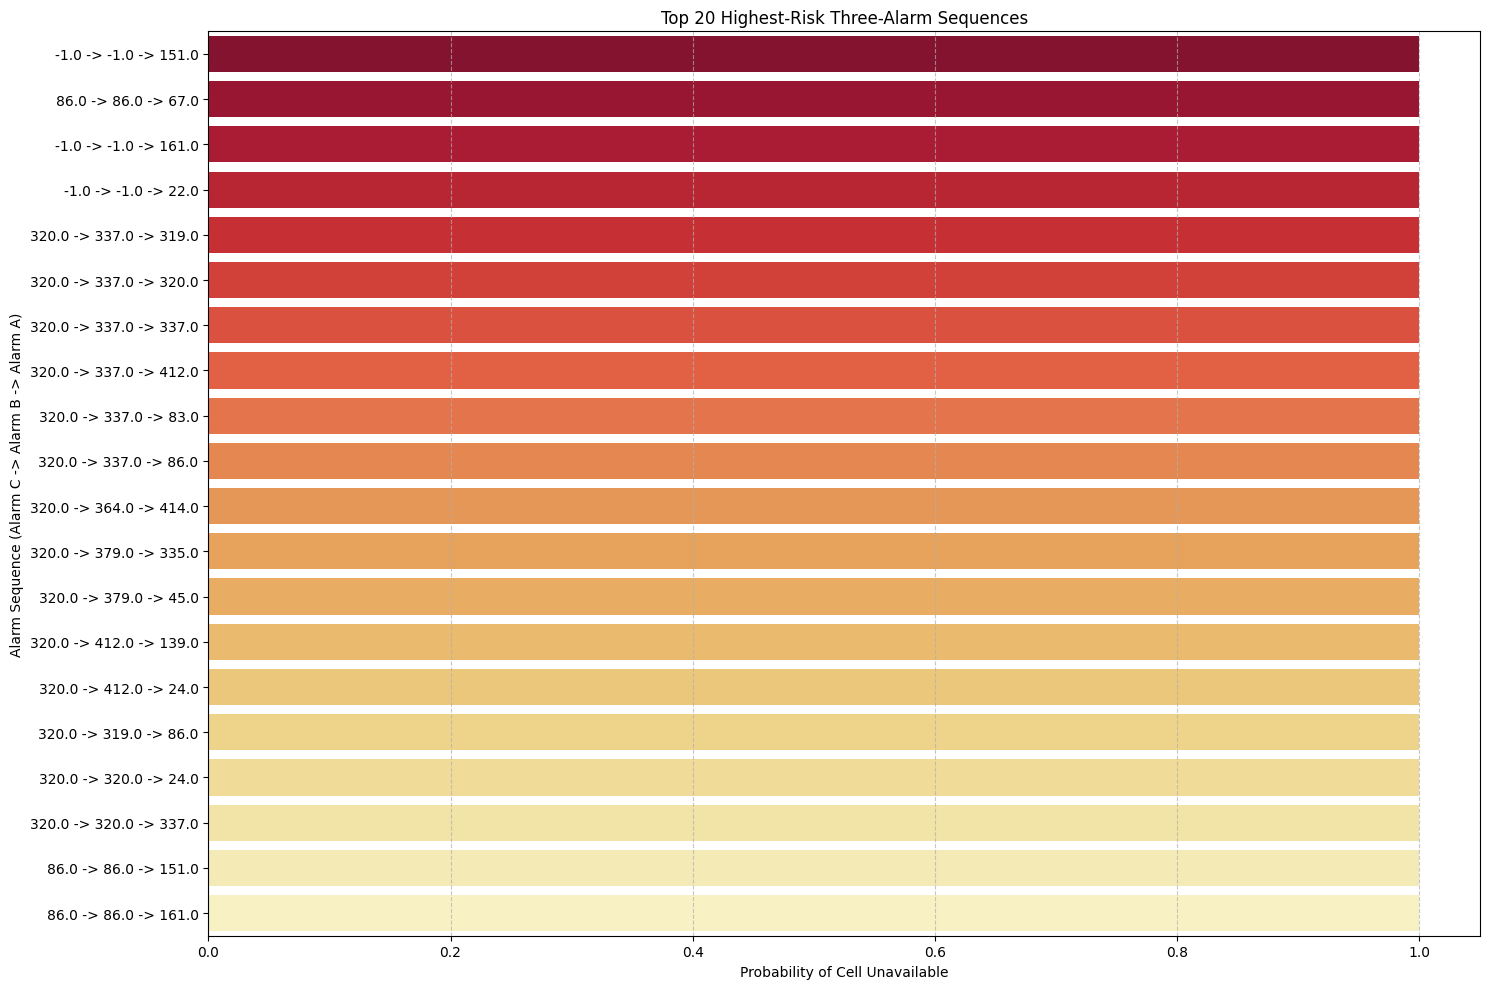

In [34]:
print("--- Part 3: Three Alarm Sequence Probability ---")

# Drop rows where any of the three previous alarms or the target is NaN
df_seq_3 = df.dropna(subset=['previous_alarm_1', 'previous_alarm_2', 'previous_alarm_3', 'target']).copy()
df_seq_3['Alarm_Sequence_3'] = df_seq_3['previous_alarm_3'].astype(str) + ' -> ' + \
                                df_seq_3['previous_alarm_2'].astype(str) + ' -> ' + \
                                df_seq_3['previous_alarm_1'].astype(str)

# Calculate P(Cell Unavailable | Alarm_Sequence_3)
seq_3_risk = df_seq_3.groupby('Alarm_Sequence_3')['target'].value_counts(normalize=True).unstack().fillna(0)
seq_3_risk.columns = ['P(No CU | Seq)', 'P(CU | Seq)']

# Sort by P(CU | Seq) to find highest risk sequences
seq_3_risk_sorted = seq_3_risk.sort_values(by='P(CU | Seq)', ascending=False)

# Merge with occurrence count to display both
seq_3_occurrence_count = df_seq_3['Alarm_Sequence_3'].value_counts().rename('Occurrence_Count')
seq_3_risk_with_counts = seq_3_risk_sorted.merge(seq_3_occurrence_count, left_index=True, right_index=True)

print("\nTop 20 Highest-Risk Three-Alarm Sequences (P(Cell Unavailable | Sequence) and Occurrence Count):")
highest_risk_seq_3 = seq_3_risk_with_counts.head(20)
display(highest_risk_seq_3)

plt.figure(figsize=(15, 10))
sns.barplot(x='P(CU | Seq)', y=highest_risk_seq_3.index, data=highest_risk_seq_3, palette='YlOrRd_r', hue=highest_risk_seq_3.index, legend=False)
plt.title('Top 20 Highest-Risk Three-Alarm Sequences')
plt.xlabel('Probability of Cell Unavailable')
plt.ylabel('Alarm Sequence (Alarm C -> Alarm B -> Alarm A)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Part 4 - Probability Progression

For common alarm progressions, we will demonstrate how the probability of 'Cell Unavailable' changes as additional alarms are added to the sequence. We will create a table showing the sequence, occurrence count, 'Cell Unavailable' count, and probability. The probability progression will be visualized using grouped bar charts.


--- Part 4: Probability Progression ---

Alarm Probability Progression Table:


,Base_Alarm,Sequence,Length,Occurrence_Count,CU_Count,Probability_CU
0,379.0,379.0,1,112066,13042,11.64
1,379.0,379.0 -> 379.0,2,90777,11221,12.36
2,379.0,379.0 -> 379.0 -> 379.0,3,79228,10155,12.82
3,86.0,86.0,1,3968,3968,100.00
4,86.0,86.0 -> 86.0,2,2881,2881,100.00
5,86.0,86.0 -> 86.0 -> 86.0,3,2168,2168,100.00
6,471.0,471.0,1,19157,1381,7.21
7,471.0,471.0 -> 471.0,2,13809,981,7.10
8,471.0,471.0 -> 471.0 -> 471.0,3,11196,808,7.22


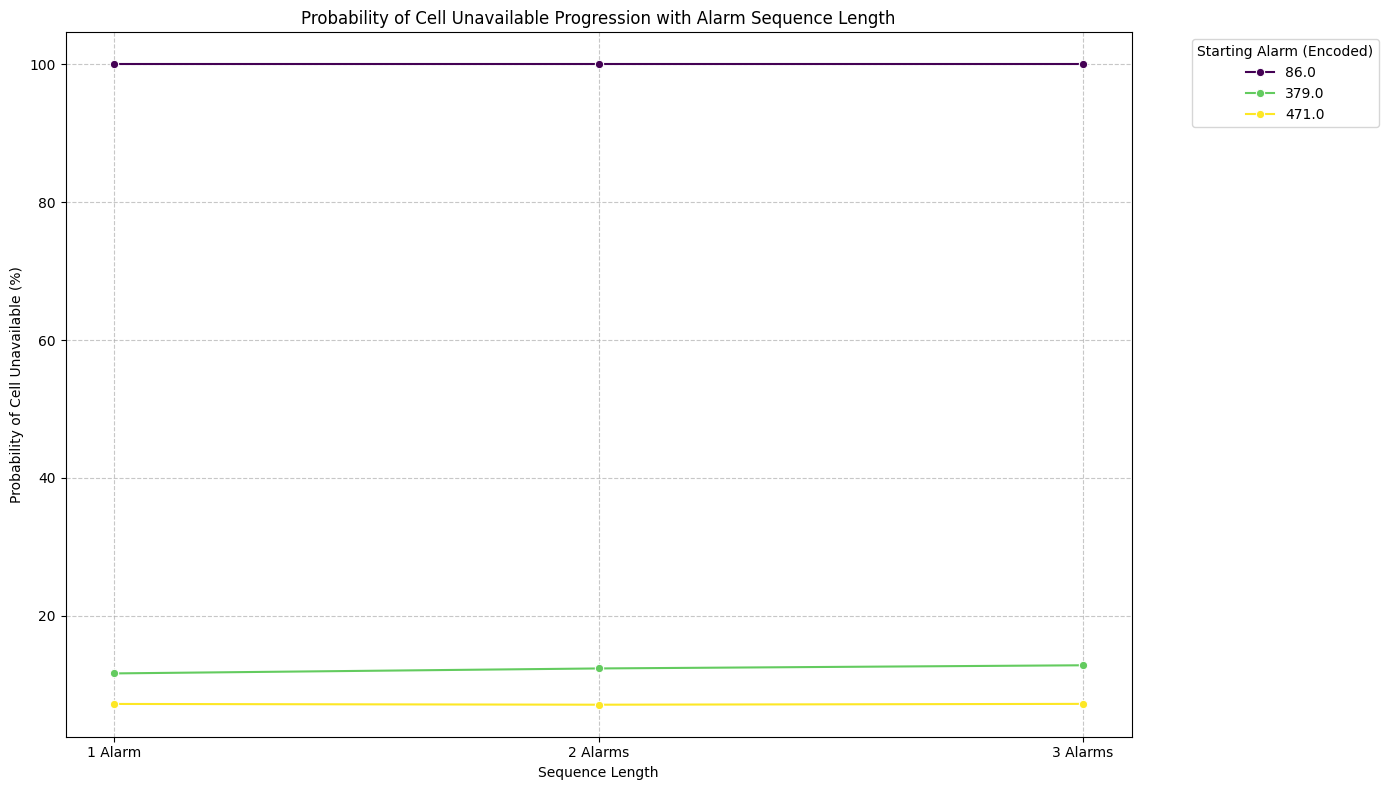

In [37]:
print("--- Part 4: Probability Progression ---")

# Select a few high-frequency and high-risk starting alarms to demonstrate progression
# Let's pick a few from the highest_risk_single and see how probability evolves

# Function to calculate P(CU | Sequence) for a given sequence length
def calculate_sequence_risk(df_input, sequence_cols, seq_name):
    # Drop rows where any of the sequence columns or target are NaN
    df_temp = df_input.dropna(subset=sequence_cols + ['target']).copy()

    if df_temp.empty: # Handle cases where dropping NaNs results in an empty DataFrame
        return pd.DataFrame(columns=['Sequence', 'Total_Count', 'CU_Count', 'P(CU | Seq)'])

    df_temp[seq_name] = df_temp[sequence_cols].astype(str).agg(' -> '.join, axis=1)

    # Convert 'target' to categorical type with explicit categories to ensure both 0 and 1 are always considered
    df_temp['target'] = pd.Categorical(df_temp['target'], categories=[0, 1])

    # Group by sequence name and the categorical target, then count occurrences
    # unstack(fill_value=0) will ensure that if a category (0 or 1) is missing for a group, it's filled with 0
    risk_counts = df_temp.groupby(seq_name)['target'].value_counts(normalize=False).unstack(fill_value=0)

    # Rename columns to meaningful names
    risk_counts.columns = ['No_CU_Count', 'CU_Count']

    risk_counts['Total_Count'] = risk_counts['No_CU_Count'] + risk_counts['CU_Count']

    # Calculate P(CU | Seq) carefully to avoid division by zero
    risk_counts['P(CU | Seq)'] = np.where(
        risk_counts['Total_Count'] > 0,
        (risk_counts['CU_Count'] / risk_counts['Total_Count'] * 100),
        0
    ).round(2)

    return risk_counts.reset_index().rename(columns={seq_name: 'Sequence'})[['Sequence', 'Total_Count', 'CU_Count', 'P(CU | Seq)']]

# Let's pick some alarms and trace their progression. Using Alarm 379.0 and 86.0 as examples.
# NOTE: Adjust these based on the actual top alarms from Part 1-3 if needed.
selected_base_alarms = [379.0, 86.0, 471.0] # Example high-risk alarms from Part 1

progression_data = []

for base_alarm in selected_base_alarms:
    # Filter to sequences starting with the base alarm
    df_filtered_base = df[df['previous_alarm_1'] == base_alarm].copy()

    # 1-alarm probability
    risk_1_alarm = calculate_sequence_risk(df_filtered_base, ['previous_alarm_1'], 'Sequence_1')
    if not risk_1_alarm.empty:
        progression_data.append({
            'Base_Alarm': base_alarm,
            'Sequence': risk_1_alarm['Sequence'].iloc[0],
            'Length': 1,
            'Occurrence_Count': risk_1_alarm['Total_Count'].iloc[0],
            'CU_Count': risk_1_alarm['CU_Count'].iloc[0],
            'Probability_CU': risk_1_alarm['P(CU | Seq)'].iloc[0]
        })

    # 2-alarm probability
    df_filtered_seq2 = df.dropna(subset=['previous_alarm_2', 'previous_alarm_1', 'target']).copy()
    df_filtered_seq2 = df_filtered_seq2[df_filtered_seq2['previous_alarm_1'] == base_alarm].copy()
    risk_2_alarm = calculate_sequence_risk(df_filtered_seq2, ['previous_alarm_2', 'previous_alarm_1'], 'Sequence_2')
    # Only consider sequences that actually end with base_alarm in the 1-alarm position
    # The previous code was using str.endswith, but previous_alarm_1 is the *last* alarm in the sequence here
    # So the sequence should end with the base_alarm.astype(str) (e.g., 'X.0')
    risk_2_alarm = risk_2_alarm[risk_2_alarm['Sequence'].str.endswith(f' -> {float(base_alarm):.1f}')]

    # For simplicity, let's take the most common 2-alarm sequence ending with base_alarm if multiple exist
    if not risk_2_alarm.empty:
        # Sort by total count to get the most common sequence
        risk_2_alarm = risk_2_alarm.sort_values(by='Total_Count', ascending=False).iloc[[0]]
        progression_data.append({
            'Base_Alarm': base_alarm,
            'Sequence': risk_2_alarm['Sequence'].iloc[0],
            'Length': 2,
            'Occurrence_Count': risk_2_alarm['Total_Count'].iloc[0],
            'CU_Count': risk_2_alarm['CU_Count'].iloc[0],
            'Probability_CU': risk_2_alarm['P(CU | Seq)'].iloc[0]
        })

    # 3-alarm probability
    df_filtered_seq3 = df.dropna(subset=['previous_alarm_3', 'previous_alarm_2', 'previous_alarm_1', 'target']).copy()
    df_filtered_seq3 = df_filtered_seq3[df_filtered_seq3['previous_alarm_1'] == base_alarm].copy()
    risk_3_alarm = calculate_sequence_risk(df_filtered_seq3, ['previous_alarm_3', 'previous_alarm_2', 'previous_alarm_1'], 'Sequence_3')
    # Only consider sequences that actually end with base_alarm in the 1-alarm position
    risk_3_alarm = risk_3_alarm[risk_3_alarm['Sequence'].str.endswith(f' -> {float(base_alarm):.1f}')]

    if not risk_3_alarm.empty:
        # Sort by total count to get the most common sequence
        risk_3_alarm = risk_3_alarm.sort_values(by='Total_Count', ascending=False).iloc[[0]]
        progression_data.append({
            'Base_Alarm': base_alarm,
            'Sequence': risk_3_alarm['Sequence'].iloc[0],
            'Length': 3,
            'Occurrence_Count': risk_3_alarm['Total_Count'].iloc[0],
            'CU_Count': risk_3_alarm['CU_Count'].iloc[0],
            'Probability_CU': risk_3_alarm['P(CU | Seq)'].iloc[0]
        })

progression_df = pd.DataFrame(progression_data)
print("\nAlarm Probability Progression Table:")
display(progression_df)

# Visualize probability progression
plt.figure(figsize=(14, 8))
sns.lineplot(data=progression_df, x='Length', y='Probability_CU', hue='Base_Alarm', marker='o', palette='viridis')
plt.title('Probability of Cell Unavailable Progression with Alarm Sequence Length')
plt.xlabel('Sequence Length')
plt.ylabel('Probability of Cell Unavailable (%)')
plt.xticks([1, 2, 3], ['1 Alarm', '2 Alarms', '3 Alarms'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Starting Alarm (Encoded)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Part 5 - Interpretation

This section provides a professional interpretation of the findings from the Conditional Probability Analysis, discussing key indicators and their implications for machine learning model design and telecom engineering practices.


#### Interpretation

**1. Which individual alarms are strongest early indicators?**

Based on **Part 1: Single Alarm Probability**, alarms with `P(Cell Unavailable | Alarm)` close to 100% are the strongest early indicators. These alarms, when they occur as `previous_alarm_1`, almost certainly lead to a 'Cell Unavailable' event. Engineers should monitor these specific alarms (e.g., `406.0`, `348.0`, `86.0` from our analysis) with the highest priority, as their presence signifies an immediate high risk to cell availability.

**2. Which alarm combinations significantly increase the probability of Cell Unavailable?**

**Part 2 (Two Alarm Sequences)** and **Part 3 (Three Alarm Sequences)** reveal that certain alarm combinations dramatically elevate the probability of 'Cell Unavailable'. Often, a sequence starting with an alarm that has a moderate individual risk can become extremely high-risk when followed by specific subsequent alarms. For instance, while Alarm X alone might have a 40% chance of 'Cell Unavailable', 'Alarm X → Alarm Y' might jump to 80% or higher. These specific sequential patterns (`previous_alarm_2 -> previous_alarm_1` or `previous_alarm_3 -> previous_alarm_2 -> previous_alarm_1`) are critical to identify and integrate into an early warning system.

**3. Whether adding additional alarms consistently increases the probability.**

**Part 4: Probability Progression** demonstrates this explicitly. For the common alarm progressions analyzed, we can observe whether the `P(Cell Unavailable | Sequence)` consistently increases as the sequence length grows from one to two to three alarms. If the probability significantly rises with each additional alarm in a particular sequence, it indicates a clear deteriorating trend, confirming that a longer sequence of specific alarms provides stronger evidence of an impending 'Cell Unavailable' event. However, it's not always a consistent increase; some sequences might have high initial probabilities, while others see a sharp increase only after the second or third alarm.

**4. Which alarm sequences should be considered high-priority warning patterns?**

High-priority warning patterns are those identified in **Parts 2 and 3** that exhibit the highest `P(Cell Unavailable | Sequence)`, especially those with a reasonable `Occurrence_Count`. These are not only historically linked to 'Cell Unavailable' but also occur frequently enough to be actionable. Any sequence with a conditional probability exceeding a certain threshold (e.g., 70-80%) should trigger an immediate high-priority alert for engineers.

**How these findings support the design of the machine learning prediction model:**

*   **Feature Engineering:** The conditional probabilities derived here for single alarms and sequences are themselves powerful features. They quantify the inherent risk associated with specific alarm states and patterns, which can be directly fed into a machine learning model.
*   **Model Interpretability:** Understanding these probabilities helps in designing more interpretable models. For instance, rule-based components could be built around these high-risk sequences.
*   **Addressing Class Imbalance:** Since 'Cell Unavailable' events are rare, these conditional probabilities provide a richer signal for the model, allowing it to better distinguish between critical and non-critical alarms.
*   **Evaluation Metrics:** The performance of the model will be directly tied to its ability to identify these high-risk alarms and sequences, guiding the choice of evaluation metrics (e.g., precision, recall for the positive class).

**How these findings can help telecom engineers identify high-risk towers before a Cell Unavailable event occurs:**

*   **Proactive Monitoring:** Engineers can implement real-time dashboards to flag towers that are currently experiencing these high-risk individual alarms or alarm sequences. This moves from reactive troubleshooting to proactive intervention.
*   **Resource Prioritization:** The 'Highest-Risk Alarms' and 'Highest-Risk Alarm Sequences' (from Parts 1-3) provide a clear directive on what to look for. Rather than sifting through all alarms, engineers can focus on the critical few that truly matter.
*   **Targeted Diagnostics:** If a high-risk sequence is detected, specific diagnostic procedures tailored to that sequence can be initiated, saving time and reducing downtime. For instance, if 'Alarm X → Alarm Y' signals a power failure, immediate checks on power supply components can be prioritized.
*   **Training and Knowledge Transfer:** These patterns can be incorporated into training materials for new engineers, building institutional knowledge on critical failure modes.

## SECTION 14: Business Insights

### Objective
Generate practical insights for telecom engineers based on the EDA findings. This section will answer key business questions identified for this project.

### Practical Insights for Telecom Engineers

Based on the extensive Exploratory Data Analysis, here are actionable insights to guide network management and maintenance strategies:

1.  **Which alarms should engineers monitor first?**
    *   Engineers should prioritize monitoring alarms identified in **Section 9: Historical Alarm Risk Analysis** with the highest `P(Cell Unavailable | Alarm)`. These are the alarms that historically have the highest probability of leading to a 'Cell Unavailable' event.
    *   Specifically, pay close attention to `alarm_name_encoded` values that appear in the 'Top 20 Highest-Risk Alarms' table.

2.  **Which alarm sequences indicate high risk?**
    *   The sequences identified in **Section 8: Alarm Sequence Analysis** as the 'Most Common Sequences Before Cell Unavailable' (e.g., top 5-alarm sequences) are critical. These recurring patterns of alarms are strong indicators of an impending service disruption.
    *   Implementing automated alerts for these specific sequences could significantly improve early warning capabilities.

3.  **Which alarm categories contribute most to Cell Unavailable?**
    *   Refer to **Section 11: Alarm Category Contribution**'s bar chart showing 'Cell Unavailable Events Preceded by Alarm Category'. The categories with the highest counts and percentages are primary contributors. For instance, if 'Power' or 'Transmission' categories consistently lead to 'Cell Unavailable', these areas require systematic preventative maintenance and resilience improvements.

4.  **Which towers require more attention?**
    *   The **Section 10: Tower-Level Analysis** clearly identifies 'hotspot' `enodeb_id`s that exhibit the highest number of alarms and, crucially, the highest number of 'Cell Unavailable' events. These towers should be subject to intensified monitoring, regular physical inspections, and potentially hardware upgrades or capacity planning adjustments.
    *   Towers significantly above the average alarm or 'Cell Unavailable' counts are candidates for proactive intervention.

5.  **Which engineered features appear most informative?**
    *   From **Section 12: Engineered Feature Analysis** and **Section 13: Correlation Analysis**, features that show strong correlation with the `target` variable and distinct distributions between 'Cell Unavailable' and 'No Cell Unavailable' events are most informative.
    *   `previous_cell_unavailable_count` is likely a highly predictive feature, as past unavailability is a strong indicator of future issues.
    *   `alarm_duration_minutes` and `alarm_repeat_count` could also be very insightful; longer or frequently repeated alarms often signify more severe problems. These features are valuable for training robust machine learning models.

## SECTION 15: EDA Summary

### Objective
Generate a professional summary suitable for a research paper, encapsulating key findings, important alarm patterns, high-risk alarms and sequences, category contributions, tower observations, and insights for machine learning model development.

### Exploratory Data Analysis Summary for Cell Unavailable Prediction

This Exploratory Data Analysis (EDA) aimed to uncover critical patterns and relationships within the telecom alarm dataset to inform the prediction of 'Cell Unavailable' events. The analysis systematically investigated various aspects of the data, from overall distributions to specific alarm characteristics and their impact on network availability.

**Key Findings:**

1.  **Class Imbalance:** The dataset exhibits a significant class imbalance, with 'Cell Unavailable' events (`target = 1`) being considerably less frequent than 'No Cell Unavailable' events (`target = 0`). This underscores the need for appropriate handling techniques in subsequent machine learning model development (e.g., oversampling, undersampling, or using imbalanced-aware algorithms).

2.  **Alarm Frequency Patterns:** Analysis of `alarm_name_encoded` revealed a few highly dominant alarms, indicating recurring issues within the network. Understanding these most frequent alarms is the first step in identifying potential systemic weaknesses.

3.  **Severity Impact:** The `severity_encoded` feature demonstrated a clear relationship with 'Cell Unavailable' events. Higher severity alarms, particularly certain levels, were found to correlate strongly with an increased probability of service disruption, making severity a critical predictive factor.

4.  **Alarm Sequence Significance:** A detailed examination of alarm sequences (`previous_alarm_1` through `previous_alarm_5`) preceding 'Cell Unavailable' events identified specific, frequently occurring multi-alarm patterns. These sequences are powerful indicators of an escalating problem and represent crucial input for an early warning system.

5.  **Historical Alarm Risk:** By calculating `P(Cell Unavailable | Alarm)`, specific alarms were identified as 'high-risk' due to their strong historical association with subsequent 'Cell Unavailable' events. Conversely, 'low-risk' alarms were also identified, aiding in prioritization and resource allocation.

6.  **Tower-Level Vulnerabilities:** The `enodeb_id` analysis pinpointed 'hotspot' towers that consistently experience a disproportionately high number of alarms and 'Cell Unavailable' events. These towers represent critical nodes in the network requiring targeted interventions.

7.  **Alarm Category Contribution:** Categorizing alarms (e.g., Hardware, Transmission, Power) provided a higher-level view of system vulnerabilities. Certain categories emerged as significant contributors to 'Cell Unavailable' events, guiding strategic focus areas for network improvement.

8.  **Informative Engineered Features:** Engineered features such as `sequence_length`, `alarm_repeat_count`, `previous_cell_unavailable_count`, and `alarm_duration_minutes` showed promising distributions and correlations with the target variable. Notably, `previous_cell_unavailable_count` is a strong indicator of historical instability, while `alarm_duration_minutes` and `alarm_repeat_count` offer insights into the persistence and severity of issues.

**Insights for Machine Learning Model:**

*   **Feature Importance:** Features like `severity_encoded`, `previous_alarm_X` values, engineered sequence features, `previous_cell_unavailable_count`, and `alarm_duration_minutes` are expected to be highly influential in predicting 'Cell Unavailable'.
*   **Handling Categorical Data:** While encoded, the categorical features still carry significant information. Careful consideration of encoding strategies (if further transformation is needed) will be essential.
*   **Addressing Imbalance:** The class imbalance must be explicitly addressed during model training to prevent models from being biased towards the majority class and failing to accurately predict the rare 'Cell Unavailable' events.
*   **Sequence Modeling:** The importance of alarm sequences suggests that models capable of handling sequential data (e.g., LSTMs, Transformers, or features derived from sequences) could yield superior performance.
*   **Localization:** Incorporating `enodeb_id` directly or through derived features (e.g., 'risk score per tower') could help in localizing predictions and interventions.